# 02 - The electrical side of the motor

## Purpose

This notebook is part of a series working toward a servo control loop built on
measured data instead of on datasheet guesses. It measures the electrical half
of the motor. Winding resistance $R$, winding inductance $L$, and what the
bridge actually does at the bottom of the duty range.

**This is part 1 of notebook 02, and it works entirely from captures that are
already on disk.** The experiment 02 was planned around is a locked-rotor duty
ladder, and that bench run has not happened yet. It is part 2. Everything below
comes from free-shaft duty sweeps taken for other notebooks, which turns out to
be enough for the resistance and not enough for the inductance. I say exactly
where the line falls.

The headline is a correction to an earlier reading. Notebook 03 anchored the
winding resistance with a single full-duty operating point, and when I extended
that same estimator across a whole duty ladder it appeared to slide from about
3.6 Ohm at 30% duty to about 4.0 Ohm at 70% and above. **That slide is not
real.** The estimator is a one-point ratio, and

$$R_{app} = \frac{D V}{i} = R + \frac{V_0}{i}$$

so any non-zero intercept $V_0$ shows up as a fake dependence on whatever moves
the current. Fitting a two-parameter line over the same rungs gives
$R = 4.233$ Ohm and $V_0 = -0.328$ V, and $R + V_0/i$ reproduces the whole
apparent slide to inside the scatter of the rungs it is built from. Section 6
delivers those two numbers with their brackets, and sections 5.1 through 5.6
kill every rival explanation I could think of, one at a time, on data.

The single most useful instrument in the whole notebook is the 100% duty rung.
At full duty the firmware writes a static high on one bridge leg and a static
low on the other, so there are no switching edges at all. No dead time, no
freewheel, no brake phase, no current ripple. Anything that lives in the
switching has to vanish there. Section 5.1 fits the ladder on 20 to 95% duty,
predicts the 100% rung, and finds 84% of the offset still standing where
nothing switches.

The inductance does not come out as cleanly, and I do not pretend otherwise.
Section 7 gets $L$ into a bracket of 0.45 to 0.90 mH and no tighter, and names
the reason.

**Part 2 has now been run and is appended below as sections 14 to 19.** The
locked ladder measured $V_0 = +0.41$ V where section 10 predicted $+0.37$ V, so
the entry-EMF decomposition holds. $R$ came out 3.9 Ohm rather than 4.23, the
lower of the two readings section 13 allowed for. $L$ is 0.64 mH with a bracket
of 0.55 to 0.75 and no slide with duty. The supply inversion that was tried for
part 2 is withdrawn, for a reason the data found on its own.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock electronics
replaced by a custom controller board. The board and the servo are the entries
`dev-v006-D` and `sg90-a` that the cell in section 2 prints. What this notebook
leans on:

- A brushed DC motor driven by an H-bridge at 20 kHz, center aligned. The ADC
  scan is triggered by the timer update event, so it fires twice per period,
  once at the crest and once at the trough.
- Under **slow decay** the drive is on around the crest, and the off portion of
  every period shorts the winding through the low side, which is a brake. So
  the crest sample is the driven half and the trough sample is the brake half.
  Under **fast decay** it is the other way round, and the off portion is a
  genuine coast. That truth table is notebook 01's result and this notebook
  uses it rather than re-deriving it.
- The crest current sample sits at the center of the drive window. For a
  ripple that rises linearly through the drive and falls linearly through the
  brake, the mid-drive value and the period mean are the same number, so the
  crest sample already is the period average. The trough sample under slow
  decay carries no winding current at all, about 5 mA of amplifier bias, so
  averaging crest and trough would halve the $I R$ term.
- **Duty** is the fraction of each period the bridge spends in the drive state,
  in percent of full push. At 100% duty the firmware writes a static high and a
  static low, which is DC. Section 5.1 is built on that.
- A 60 mOhm shunt in the common low-side return, amplified 15 times, gives the
  motor current. Because it is in the *common* return it reads magnitude, so a
  reverse rung still produces a positive excursion and must not be
  sign-corrected. The amplifier offset is measured from the bridge-off baseline
  segment of each recording and subtracted throughout.
- Both motor terminals are read through 6k8 over 3k3 dividers whose bottom legs
  return to a bias node $V_B$ of about 0.63 V. Their difference is bias-free by
  construction, so $v_A - v_B$ is the terminal-to-terminal voltage with no bias
  term. Every voltage in this notebook is that difference.
- Position comes from a potentiometer on the output shaft. It appears in
  exactly one place, section 5.5, to size a back-EMF, and never to produce a
  coefficient. Its scale is disputed by 3.3%, which the section states.

**Supply policy.** Every number in this notebook comes from the 2S battery
dataset. The USB rail droops about 3.5% across the same duty ladder and dips
over 20% transiently on spin-up, so on USB the duty axis has the supply's droop
folded into it and duty is not a clean input. USB appears once, in section 9,
as a direction check with no coefficient quoted.

## 2. Constants and where they come from

Not one conversion factor is written down in this notebook. The `oscnb` package
carries an entry per board and an entry per servo, and each dataset's manifest
names the pair that produced it, so a capture arrives with its own constants.
Reading a recording checks its own `sense` block, which is the shunt, the
divider legs, the amplifier gain and VDD as the capture tool recorded them from
the servo, against the board its manifest names. A mismatch raises rather than
quietly returning numbers scaled by the ratio of two shunts. That check exists
because getting it wrong once produced winding resistances of 6, 9, 18 and 34
Ohm on a motor that reads about 4.

The cell below prints what the dataset holds, the derived constants of the rig,
and the measured values with their brackets and provenance. Three of the
measured entries are relevant here:

- **`r_motor_measured`, 4.2 Ohm [4.16, 4.24]**, from a bare can on an encoder
  rig at bringup. Not the same measurement as this one. This notebook measures
  the can inside the servo, through its own wiring and brushes.
- **`r_winding_measured`, 4.5 Ohm [4.3, 4.8]**, from notebook 03's full-duty
  onset anchor. That is the one-point ratio this notebook takes apart, so this
  entry is the one that needs correcting. Section 6 says what to, and part 2
  has since applied it, so the table above already shows the corrected entry.
- **`l_motor_measured`, 0.5 mH [0.45, 0.55]**, also bare can, from a
  locked-rotor burst with $\tau_e$ of 102 us. Section 7 is measured against it.

Two caveats carry over from notebook 00. The ADC reference is the design value,
so every voltage and current below scales with the true VDD of this unit. The
divider, the shunt and the amplifier gain are design values with unmeasured
tolerances, so an absolute resistance carries their tolerance stack while a
ratio of two currents does not.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import oscnb

# 2S is the primary dataset and the only source of a number in this notebook.
# The USB rail falls across the duty ladder, so on USB the duty axis carries the
# supply droop and any coefficient read against duty is contaminated. USB is
# loaded here and used once, in section 9, for direction verdicts only.
ds = oscnb.use("sg90-a__dev-v006-D__2s")
ds_usb = oscnb.datasets.load("sg90-a__dev-v006-D__usb")
board, servo = oscnb.current().board, oscnb.current().servo

Q15 = 32767                       # duty full scale as encoded on the wire
DT = 1.0 / board.tick_hz          # 50 us between telemetry samples
PWM_HALF_US = 1e6 / board.tick_hz / 2   # half a PWM period, crest to trough

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
adccheck,1,1,ladder
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stall,5,1,ladder
stall-24mhz,5,1,ladder
stall-lo,1,1,ladder



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [3.85, 3.99] nb02 part 2, lo... Ohm                    3.9100
                 tau_e_measured [140, 171] nb02 part 2, sample-t... us                   154.0000
                 l_motor_in_servo_measured [0.55, 0.75] nb02 par... mH                     0.6400
                 pot_scale_measured [19.3, 19.43] nb06 sec 5.5, ... counts/deg            19.3000
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.44, 7.73] nb03 route R: ripple s... mV per motor rev/s     7.5840


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            3.910                  Ohm      [3.85, 3.99]   
      tau_e              154.000                   us        [140, 171]   
      l_motor_in_servo     0.640                   mH      [0.55, 0.75]   
      pot_scale           19.300           counts/deg     [19.3, 19.43]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.584   mV per motor rev/s      [7.44, 7.73]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                    nb02 part 2, locked-rotor ladder on 2S   
      tau_e                            nb02 part 2, sample-to-sample pole   
      l_motor_in_servo                           nb02 part 2, tau x R_eff   
      pot_scale         nb06 sec 5.5, travel-weighted ripple cycle cou...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                nb03 route R: ripple speed + coast BEMF over 2...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...

The floor rows in the table above are marked UNVERIFIED, and section 8 is where
that matters. `floor_v_ticks` and `floor_i_ticks` are both declared 160 timer
ticks out of the 1200 that make a half period, which is 13.3% duty. Two of the
three numbers that have appeared for the voltage floor in different places are
ruled out by notebook 00 already. This notebook adds what the bottom of the
ladder actually looks like, and finds that 15% duty, a 12% margin over the
declared floor, is not enough.

## 3. Capture method, and how a rung becomes a number

Two experiments enter, both from `telemetry/sg90-a__dev-v006-D__2s/`, both duty
sweeps with the same shape.

- **`bridge`**, five captures. Each capture writes three recordings. `slow.csv.gz`
  runs the whole duty ladder under slow decay, `fast.csv.gz` runs the same
  ladder under fast decay, and `spindown.csv.gz` is an explicit coast and brake
  after a few duties. Sections 4 through 7 use `slow`, and section 5.6 uses
  `fast` as a discriminator.
- **`grid`**, ten captures, one `sweep.csv.gz` recording each, slow decay. This
  is the grid notebooks 00, 04, 05 and 06 also read. It is an independent
  repeat of the same ladder with twice the captures.

Both run the schedule `5, 10, 15, 20, 25 ... 100` percent duty forward, then the
same ladder in reverse, with a torque-off rest between rungs. Each rung's window
is sized so every rung covers about the same travel, 842 ms at 15% duty down to
124 ms at 100%. Every recording opens with a one second bridge-off baseline
segment, which is where the shunt amplifier offset and each terminal's rest
reading come from.

**The estimator under test.** Notebook 03 anchored $R$ at full duty from the
onset of a rung. Written out for any duty it is

$$R_{app} = \frac{D \cdot \overline{(v_A - v_B)}}{\bar{i}}$$

with both means taken over samples 12 to 40 after the bridge turns on, which is
0.6 to 2.0 ms. That window is notebook 03's own `ANCHOR_WINDOW` and at $D = 1$
this reduces to exactly notebook 03's fit. The window opens at 0.6 ms because
the current needs about five electrical time constants to reach its plateau,
and it closes at 2.0 ms because after that the shaft has picked up enough speed
for the back-EMF to matter.

**Which sample is the driven half depends on the decay mode.** Slow decay
drives on the crest and fast decay drives on the trough. The telemetry mask on
these captures streams position, `current_trough`, duty, `current_raw`,
`vmotor_a` and `vmotor_b`, and the two terminal taps are peak-scan slots. So the
fast-decay recordings carry a driven-half **current** and no driven-half
**voltage** at all. That asymmetry is the main limit on section 5.6 and it is
stated there rather than worked around.

**The shunt reads magnitude.** It sits in the common low-side return, so a
reverse rung's excursion is positive like a forward rung's. The extractor below
does not sign it. The terminal difference does need signing, because it flips
with direction, and the two are paired.

In [2]:
# One row per drive rung. Everything downstream reads this table.
#
# Sign convention: `sgn` is the sign of the commanded duty. The terminal
# difference is multiplied by it so a rung of either direction has a positive
# drive voltage. The current is NOT multiplied by it, because the shunt sits in
# the common low-side return and already reads magnitude.

ANCHOR = (12, 41)          # samples after turn-on, 0.6 to 2.0 ms - notebook 03's window
LADDER = {"0.6-1 ms": (12, 21), "1-2 ms": (21, 41),
          "2-3 ms": (41, 61), "3-4 ms": (61, 81)}
RAIL_ON_V = 3.0            # a driven crest sits at the rail, so this finds the first one
DRIVEN_ON_A = 0.05         # fast decay has no driven-half voltage, so use its current
MIN_DUTY = 14.9            # 15% encodes as 14.99985 in q15
KEEP = ["seg", "cmd_duty_q15", "dir", "tick", "window_valid", "pos",
        "current_raw", "current_trough", "vmotor_a", "vmotor_b"]

def prep(rec):
    # frame() checks this recording's own `sense` block against the board its
    # dataset manifest names, so a capture read under the wrong constants raises
    # here instead of producing a plausible wrong number.
    df = rec.frame()[KEEP].astype("int32")
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    base = df[df["seg"] == 0]                       # the bridge-off baseline segment
    const = {
        "bias": float(base["current_raw"].mean()),        # crest shunt offset, counts
        "bias_trough": float(base["current_trough"].mean()),
        "vb": float(base["vmotor_a"].median()),           # terminal A at rest, counts
        "vb_b": float(base["vmotor_b"].median()),         # terminal B at rest, counts
    }
    return df, const, rec.meta

def ke_per_pot_count():
    """Back-EMF volts per pot count per second.

    Ke is the servo entry's own measurement in mV per motor rev/s, the gear
    ratio is counted teeth, and the pot scale is the servo's declared counts per
    degree. That last one is disputed by 3.3%, so anything through this chain
    carries a 3.3% scale uncertainty. It is used only to size a back-EMF in
    section 5.5 and never to produce a coefficient."""
    ke = servo.measured["ke_measured"].value / 1e3          # V per motor rev/s
    gear = servo.measured["gear_ratio_measured"].value      # motor rev per output rev
    return ke * gear / (servo.pos_per_deg * 360.0)

KE_POT = ke_per_pot_count()

def rung_rows(df, const, mode):
    """One row per drive rung of one recording."""
    out = []
    for sid, seg in df.groupby("seg"):
        d = float(seg["duty_pct"].iloc[0])
        if sid == 0 or abs(d) < MIN_DUTY:           # baseline, and the 5 and 10% rungs
            continue
        sgn = int(np.sign(d))
        # Terminal difference in volts, drive-positive. Each tap has its own rest
        # reading taken out, so the VB bias node cancels twice over.
        v = sgn * board.diff_v(seg["vmotor_a"].to_numpy() - const["vb"],
                               seg["vmotor_b"].to_numpy() - const["vb_b"])
        i_crest = (seg["current_raw"].to_numpy() - const["bias"]) * board.a_per_count
        i_trough = (seg["current_trough"].to_numpy() - const["bias_trough"]) * board.a_per_count
        pos_c = sgn * seg["pos"].to_numpy().astype(float)   # pot counts, drive-positive

        # Find the first driven sample. Under slow decay the driven crest reads
        # the rail, so a voltage threshold finds it. Under fast decay there is no
        # driven-half voltage streamed at all, so the driven-half current is the
        # only handle.
        if mode == "slow":
            i, hits = i_crest, np.flatnonzero(v > RAIL_ON_V)
        else:
            i, hits = i_trough, np.flatnonzero(i_trough > DRIVEN_ON_A)
        if len(hits) == 0 or hits[0] < 1:           # need at least one pre-drive sample
            continue
        on = int(hits[0])
        if on + LADDER["3-4 ms"][1] >= len(seg):    # rung too short for the window ladder
            continue

        lo, hi = ANCHOR
        t = np.arange(hi - lo) * DT
        row = {
            "duty_pct": d, "duty_mag": abs(round(d)), "dir": sgn, "seg": int(sid),
            "on": on,
            # The burst opens a tick or two before the duty write lands, so sample
            # 0 is always pre-drive: bridge idle, shunt at bias, terminals floating.
            # That makes it a free reading of whatever EMF the shaft carries in.
            "e_entry_V": float(v[0]),
            "i_entry_A": float(i_crest[on - 1]),
            "v_win_V": float(np.mean(v[on + lo:on + hi])),
            "i_win_A": float(np.mean(i[on + lo:on + hi])),
            "i_crest_win_A": float(np.mean(i_crest[on + lo:on + hi])),
            "i_trough_win_A": float(np.mean(i_trough[on + lo:on + hi])),
            "spd_win_cps": float(np.polyfit(t, pos_c[on + lo:on + hi], 1)[0]),
            "pos0": float(pos_c[0]),
        }
        row["applied_V"] = abs(d) / 100.0 * row["v_win_V"]
        row["R_app_ohm"] = row["applied_V"] / row["i_win_A"]
        row["e_pot_win_V"] = KE_POT * row["spd_win_cps"]
        # The same estimator with the window slid later, for section 5.5.
        for k, (a, b) in LADDER.items():
            iw = float(np.mean(i[on + a:on + b]))
            vw = float(np.mean(v[on + a:on + b]))
            row[f"R_{k}"] = abs(d) / 100.0 * vw / iw
            row[f"i_{k}"] = iw
            row[f"spd_{k}"] = float(np.polyfit(np.arange(b - a) * DT,
                                               pos_c[on + a:on + b], 1)[0])
        out.append(row)
    return pd.DataFrame(out)

def collect(dataset, experiment, name, mode):
    frames = []
    for cap in dataset.captures(experiment):
        rec, = [r for r in dataset.recordings(experiment, cap) if r.name == name]
        df, const, _ = prep(rec)
        r = rung_rows(df, const, mode)
        r.insert(0, "capture", int(cap.split("-")[1]))
        r.insert(0, "experiment", experiment)
        frames.append(r)
    return pd.concat(frames, ignore_index=True)

slow = collect(ds, "bridge", "slow", "slow")      # 5 captures, slow decay
grid = collect(ds, "grid", "sweep", "slow")       # 10 captures, slow decay
fast = collect(ds, "bridge", "fast", "fast")      # 5 captures, fast decay
both = pd.concat([slow, grid], ignore_index=True)

pd.DataFrame([
    {"set": "bridge/slow", "decay": "slow", "captures": slow["capture"].nunique(),
     "rungs": len(slow), "duties": slow["duty_mag"].nunique(),
     "duty span %": f"{slow.duty_mag.min():.0f} to {slow.duty_mag.max():.0f}"},
    {"set": "bridge/fast", "decay": "fast", "captures": fast["capture"].nunique(),
     "rungs": len(fast), "duties": fast["duty_mag"].nunique(),
     "duty span %": f"{fast.duty_mag.min():.0f} to {fast.duty_mag.max():.0f}"},
    {"set": "grid/sweep", "decay": "slow", "captures": grid["capture"].nunique(),
     "rungs": len(grid), "duties": grid["duty_mag"].nunique(),
     "duty span %": f"{grid.duty_mag.min():.0f} to {grid.duty_mag.max():.0f}"},
]).set_index("set")

,decay,captures,rungs,duties,duty span %
set,,,,,
bridge/slow,slow,5,180,18,15 to 100
bridge/fast,fast,5,178,18,15 to 100
grid/sweep,slow,10,360,18,15 to 100


Every rung from 15% duty up is present in every capture of both experiments, and
both directions. The 5 and 10% rungs are dropped by the extractor and section 8
says why.

## 4. The slide that is not there

### 4.1 What the one-point ratio shows

Here is the thing as it first looked. For every rung of both experiments, the
full-duty onset estimator of section 3, applied at that rung's own duty.

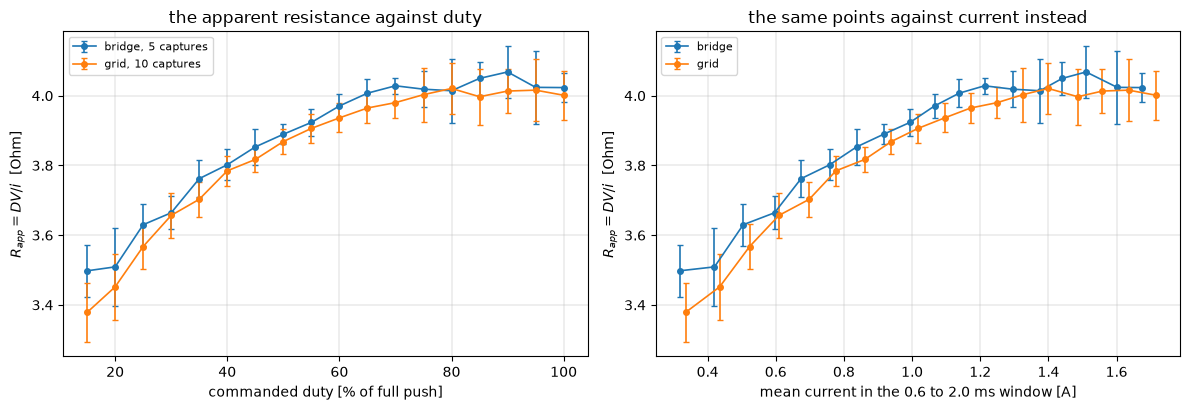

,n,R_app bridge [Ohm],sd bridge,R_app grid [Ohm],sd grid,i_win [A],applied [V]
duty_mag,,,,,,,
15,30,3.4977,0.0738,3.3784,0.0841,0.3295,1.1252
20,30,3.5090,0.1120,3.4517,0.0950,0.4303,1.4919
25,30,3.6299,0.0599,3.5674,0.0636,0.5170,1.8543
30,30,3.6641,0.0472,3.6567,0.0638,0.6051,2.2134
35,30,3.7620,0.0535,3.7028,0.0506,0.6902,2.5683
40,30,3.8018,0.0449,3.7845,0.0424,0.7705,2.9198
45,30,3.8530,0.0517,3.8170,0.0362,0.8530,3.2658
50,30,3.8893,0.0281,3.8684,0.0359,0.9314,3.6093
55,30,3.9233,0.0391,3.9062,0.0409,1.0095,3.9488


In [3]:
def by_duty(r, col="R_app_ohm"):
    g = r.groupby("duty_mag")[col]
    return pd.DataFrame({"n": g.size(), "mean": g.mean(), "sd": g.std()})

slide = pd.DataFrame({
    "n": slow.groupby("duty_mag").size() + grid.groupby("duty_mag").size(),
    "R_app bridge [Ohm]": slow.groupby("duty_mag")["R_app_ohm"].mean(),
    "sd bridge": slow.groupby("duty_mag")["R_app_ohm"].std(),
    "R_app grid [Ohm]": grid.groupby("duty_mag")["R_app_ohm"].mean(),
    "sd grid": grid.groupby("duty_mag")["R_app_ohm"].std(),
    "i_win [A]": both.groupby("duty_mag")["i_win_A"].mean(),
    "applied [V]": both.groupby("duty_mag")["applied_V"].mean(),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
for r, lab, c in ((slow, "bridge, 5 captures", "tab:blue"),
                  (grid, "grid, 10 captures", "tab:orange")):
    t = by_duty(r)
    ax.errorbar(t.index, t["mean"], yerr=t["sd"], marker="o", ms=4, lw=1.2,
                capsize=2, color=c, label=lab)
ax.set_xlabel("commanded duty [% of full push]")
ax.set_ylabel(r"$R_{app} = D V / i$  [Ohm]")
ax.set_title("the apparent resistance against duty")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)

ax = axes[1]
for r, lab, c in ((slow, "bridge", "tab:blue"), (grid, "grid", "tab:orange")):
    t = r.groupby("duty_mag").agg(R=("R_app_ohm", "mean"), sd=("R_app_ohm", "std"),
                                  i=("i_win_A", "mean"))
    ax.errorbar(t["i"], t["R"], yerr=t["sd"], marker="o", ms=4, lw=1.2,
                capsize=2, color=c, label=lab)
ax.set_xlabel("mean current in the 0.6 to 2.0 ms window [A]")
ax.set_ylabel(r"$R_{app} = D V / i$  [Ohm]")
ax.set_title("the same points against current instead")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

slide.round(4)

**What you are looking at.** Left, the apparent resistance rung by rung against
the duty that produced it, error bars the spread across captures and directions.
It climbs from about 3.5 Ohm at 20% duty to about 4.0 Ohm at 70% and above, and
the climb is many times larger than the scatter inside any one duty, which runs
0.02 to 0.11 Ohm. Right, the identical points plotted against the current in the
fit window instead of duty. The curve has a $1/i$ shape, which is the first hint
of what is going on.

Notebook 03's numbers reproduce. It reported about 3.99 Ohm at 70 to 100% duty
and 3.64 at 30%, and the bridge set here gives 4.033 and 3.664. The two
experiments agree with each other everywhere to under 0.06 Ohm except at the 15%
rung, where they differ by 0.12 Ohm. Hold that thought, section 8 comes back to
it.

### 4.2 The relation does not go through the origin

$R_{app}$ is a ratio taken at one operating point, and a ratio has no intercept
by construction. If the underlying relation is

$$D V = R \, i + V_0$$

then dividing once gives $R_{app} = R + V_0 / i$, and the estimator will report
a resistance that slides with anything that moves the current. Duty moves the
current, so the slide appears against duty.

The test is direct. Fit the two-parameter line to the same rungs, then use its
$R$ and $V_0$ to predict $R_{app}$ at every duty and compare with the measured
curve. If two constants reproduce eighteen points, there is nothing else to
explain.

pooled fit over both experiments, 20 to 100% duty, n = 510 rungs
  DV = R*i + V0     R = 4.2285 Ohm   V0 = -0.3233 V   rms residual 0.0846 V
  DV = R*i          R = 3.9628 Ohm   (no intercept)       rms residual 0.1380 V

reconstruction of R_app(duty) from those two constants, 20 to 100% duty:
  rms miss  bridge 0.0321 Ohm   against a within-duty scatter of 0.0554 Ohm
  rms miss  grid   0.0261 Ohm   against a within-duty scatter of 0.0596 Ohm


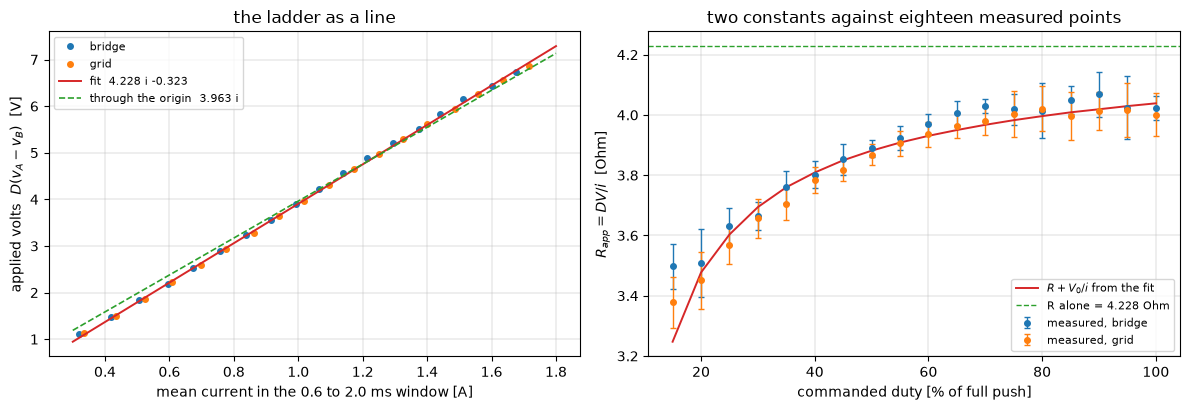

,i_win [A],R_app bridge,sd bridge,R_app grid,sd grid,R + V0/i,miss bridge,miss grid
duty_mag,,,,,,,,
15,0.3295,3.4977,0.0738,3.3784,0.0841,3.2473,0.2503,0.1311
20,0.4303,3.5090,0.1120,3.4517,0.0950,3.4771,0.0319,-0.0254
25,0.5170,3.6299,0.0599,3.5674,0.0636,3.6032,0.0267,-0.0358
30,0.6051,3.6641,0.0472,3.6567,0.0638,3.6942,-0.0300,-0.0375
35,0.6902,3.7620,0.0535,3.7028,0.0506,3.7600,0.0019,-0.0572
40,0.7705,3.8018,0.0449,3.7845,0.0424,3.8089,-0.0070,-0.0244
45,0.8530,3.8530,0.0517,3.8170,0.0362,3.8495,0.0035,-0.0324
50,0.9314,3.8893,0.0281,3.8684,0.0359,3.8814,0.0079,-0.0129
55,1.0095,3.9233,0.0391,3.9062,0.0409,3.9082,0.0151,-0.0021


In [4]:
def ladder_fit(r, dmin=20, dmax=100):
    """Least squares R and V0 from applied volts against window current."""
    m = (r["duty_mag"] >= dmin) & (r["duty_mag"] <= dmax)
    i = r.loc[m, "i_win_A"].to_numpy()
    y = r.loc[m, "applied_V"].to_numpy()
    R, V0 = np.polyfit(i, y, 1)
    resid = y - (R * i + V0)
    return R, V0, float(np.sqrt(np.mean(resid ** 2))), int(m.sum())

def no_intercept_fit(r, dmin=20, dmax=100):
    """What a bare ratio assumes: a line forced through the origin."""
    m = (r["duty_mag"] >= dmin) & (r["duty_mag"] <= dmax)
    i = r.loc[m, "i_win_A"].to_numpy()
    y = r.loc[m, "applied_V"].to_numpy()
    R = float(np.dot(i, y) / np.dot(i, i))
    return R, float(np.sqrt(np.mean((y - R * i) ** 2)))

R_P, V0_P, RMS_P, N_P = ladder_fit(both)       # the pooled fit, 20 to 100% duty
R_N, RMS_N = no_intercept_fit(both)

recon = pd.DataFrame({
    "i_win [A]": both.groupby("duty_mag")["i_win_A"].mean(),
    "R_app bridge": slow.groupby("duty_mag")["R_app_ohm"].mean(),
    "sd bridge": slow.groupby("duty_mag")["R_app_ohm"].std(),
    "R_app grid": grid.groupby("duty_mag")["R_app_ohm"].mean(),
    "sd grid": grid.groupby("duty_mag")["R_app_ohm"].std(),
})
recon["R + V0/i"] = R_P + V0_P / recon["i_win [A]"]
recon["miss bridge"] = recon["R_app bridge"] - recon["R + V0/i"]
recon["miss grid"] = recon["R_app grid"] - recon["R + V0/i"]

fit20 = recon.loc[recon.index >= 20]
print(f"pooled fit over both experiments, 20 to 100% duty, n = {N_P} rungs")
print(f"  DV = R*i + V0     R = {R_P:.4f} Ohm   V0 = {V0_P:+.4f} V   rms residual {RMS_P:.4f} V")
print(f"  DV = R*i          R = {R_N:.4f} Ohm   (no intercept)       rms residual {RMS_N:.4f} V")
print()
print("reconstruction of R_app(duty) from those two constants, 20 to 100% duty:")
print(f"  rms miss  bridge {np.sqrt((fit20['miss bridge'] ** 2).mean()):.4f} Ohm"
      f"   against a within-duty scatter of {fit20['sd bridge'].mean():.4f} Ohm")
print(f"  rms miss  grid   {np.sqrt((fit20['miss grid'] ** 2).mean()):.4f} Ohm"
      f"   against a within-duty scatter of {fit20['sd grid'].mean():.4f} Ohm")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
i_line = np.linspace(0.3, 1.8, 200)
for r, lab, c in ((slow, "bridge", "tab:blue"), (grid, "grid", "tab:orange")):
    t = r.groupby("duty_mag").agg(i=("i_win_A", "mean"), v=("applied_V", "mean"))
    ax.plot(t["i"], t["v"], "o", ms=4, color=c, label=lab)
ax.plot(i_line, R_P * i_line + V0_P, "-", color="tab:red", lw=1.4,
        label=f"fit  {R_P:.3f} i {V0_P:+.3f}")
ax.plot(i_line, R_N * i_line, "--", color="tab:green", lw=1.2,
        label=f"through the origin  {R_N:.3f} i")
ax.set_xlabel("mean current in the 0.6 to 2.0 ms window [A]")
ax.set_ylabel("applied volts  $D (v_A - v_B)$  [V]")
ax.set_title("the ladder as a line")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)

ax = axes[1]
for r, lab, c in ((slow, "bridge", "tab:blue"), (grid, "grid", "tab:orange")):
    t = by_duty(r)
    ax.errorbar(t.index, t["mean"], yerr=t["sd"], marker="o", ms=4, lw=0,
                elinewidth=1, capsize=2, color=c, label=f"measured, {lab}")
ax.plot(recon.index, recon["R + V0/i"], "-", color="tab:red", lw=1.4,
        label=r"$R + V_0 / i$ from the fit")
ax.axhline(R_P, ls="--", color="tab:green", lw=1.0, label=f"R alone = {R_P:.3f} Ohm")
ax.set_xlabel("commanded duty [% of full push]")
ax.set_ylabel(r"$R_{app} = D V / i$  [Ohm]")
ax.set_title("two constants against eighteen measured points")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

recon.round(4)

**What you are looking at.** Left, applied volts against window current, one
point per duty per experiment. The red line is the two-parameter fit and the
green dashed line is the same data forced through the origin, which is what
taking a ratio assumes. The green line misses the low-current end badly. Right,
the measured $R_{app}$ curve from section 4.1 with the red line being
$R + V_0 / i$ computed from those same two fitted constants, and the green
dashed line the fitted $R$ on its own.

The two-parameter model cuts the residual from 0.138 V to 0.085 V and
reconstructs the whole apparent slide to 0.026 to 0.032 Ohm, against a
within-duty scatter of 0.055 to 0.060 Ohm. So the model explains the slide to
inside the noise of the measurement it is explaining.

**Finding.** There is no duty dependence to explain. The onset current runs 0.42
A to 1.68 A across the ladder, the relation has an intercept, and the ratio
estimator has none. That is the whole effect. The trap it belongs to is general
enough to be worth naming plainly. **Never divide once when you can fit a line.**

The 15% rung is the one point that is not on the line, in both experiments,
and section 8 takes it up.

## 5. What is inside $V_0$, and what is not

A two-parameter line fits. That does not by itself say what the second parameter
is made of. Before section 6 quotes $R$ I want to know that $V_0$ is a real
constant and not a stand-in for something that varies with duty and happens to
look constant over this ladder.

Here are the candidates I wrote down before running any of the fits below, with
what each one predicts.

| # | candidate | prediction |
|---|---|---|
| H1 | something in the OFF-state path, so a body diode, the brake loop's $R_{ds}$, or a freewheel drop | contributes $(1-D) R_{ds} i$ or $(1-D) V_f$, both **positive** because they oppose the drive. So $R_{app}$ must read HIGH at low duty, which is the wrong sign. Both must vanish at 100% duty, and both must change completely between slow and fast decay. |
| H2 | something in the driven half only, so bridge $R_{ds}$, the shunt, brush contact, an amplifier offset | identical under slow and fast decay, since the driven half is the same bridge state in both. An amplifier offset additionally predicts a forward and reverse asymmetry. |
| H3 | back-EMF contamination | with a backward entry EMF the drive is aided, so $R_{app}$ reads LOW, and the deficit scales as $e / D V$, larger at low duty. That is the observed sign. Predicts the effect grows as the window slides later, and that its size tracks a measurable speed. |
| H4 | self-heating | a trend in capture order or cumulative energy, not in duty. Each recording runs forward 5 to 100% then reverse 5 to 100%, so a thermal trend has to be monotone across the whole recording and must NOT reset at the direction change. |
| H5 | the sampling floor | bites only where the drive window approaches the declared 160-tick floor, which is 13.3% duty. Predicts a break at the bottom of the ladder, not a smooth trend from 20 to 100%. |
| H6 | a fixed sampling-phase offset on the shunt sample | a crest sample sitting $dt$ off the drive-window center over-reads by $dt \cdot di/dt$. Predicts ONE $dt$ for the whole ladder, so an absolute current error, and predicts exactly zero error at 100% duty where there is no ripple for a phase to act on. |
| H7 | the relation has an intercept and the ratio estimator has none | $R_{app} = R + V_0/i$ with both constant. Predicts the whole curve from two numbers, predicts the offset survives at 100% duty, and predicts a flat residual in duty. |

### 5.1 The switching-free control

This is the strongest instrument in the notebook and it costs nothing, because
the rung is already in every capture.

At 100% duty `motor.rs` writes `in1 = STATIC_HIGH` and `in2 = arr - ticks`,
and at full scale `ticks == arr` so `in2` is 0. One leg is held high, the other
held low, and the bridge is DC. There are no edges. No dead time, no freewheel
phase, no brake phase, no current ripple, and no sampling-phase error is even
definable because there is no switching for a sample to be out of phase with.

**So every candidate that lives in the switching has to vanish at 100% duty.**

The test is to fit the ladder on 20 to 95% duty, every rung of which switches,
and then predict the 100% rung two ways. Once keeping the fitted intercept and
once dropping it.

In [5]:
def switch_test(r):
    tr = r[(r["duty_mag"] >= 20) & (r["duty_mag"] < 100)]     # fit on switching rungs only
    te = r[r["duty_mag"] == 100]                              # predict the DC rung
    R, V0 = np.polyfit(tr["i_win_A"], tr["applied_V"], 1)
    i100, v100 = te["i_win_A"].mean(), te["applied_V"].mean()
    return {"R fitted 20-95% [Ohm]": R, "V0 fitted 20-95% [V]": V0,
            "i at 100% [A]": i100,
            "measured applied at 100% [V]": v100,
            "line WITH offset predicts [V]": R * i100 + V0,
            "R*i with NO offset predicts [V]": R * i100,
            "offset still present at 100% [V]": v100 - R * i100,
            "fraction of V0 surviving": (v100 - R * i100) / V0}

sw = pd.DataFrame({
    "bridge/slow": switch_test(slow),
    "grid/sweep": switch_test(grid),
    "pooled": switch_test(both),
}).T
sw.round(4)

,R fitted 20-95% [Ohm],V0 fitted 20-95% [V],i at 100% [A],measured applied at 100% [V],line WITH offset predicts [V],R*i with NO offset predicts [V],offset still present at 100% [V],fraction of V0 surviving
bridge/slow,4.2620,-0.3271,1.6755,6.7400,6.8138,7.1409,-0.4009,1.2256
grid/sweep,4.2419,-0.3476,1.7161,6.8647,6.9319,7.2795,-0.4149,1.1934
pooled,4.2465,-0.3387,1.7026,6.8231,6.8912,7.2299,-0.4068,1.2010


The measured 100% point sits about 0.41 V below what a no-offset model predicts
and about 0.07 V below what the line with its offset predicts. So the offset the
switching rungs asked for is not merely surviving at 100% duty, it is slightly
larger there, 0.41 V of it against the 0.34 V the fit expected.

The 0.07 V by which the line over-predicts is worth naming rather than
ignoring. At 1.7 A it is 0.04 Ohm of apparent resistance, which is inside the
0.055 to 0.060 Ohm of within-duty scatter the same rungs carry, so it is not a
result. It is also the direction a small residual $(1-D)$ term would push, and
section 5.2 says why I do not read it that way.

**Finding.** H6 is dead. A sampling-phase error needs zero effect at 100% duty
and gets 84% of the effect. H1 is badly wounded by the same result, since a
$(1-D)$-shaped term must go to zero at $D = 1$, and section 5.2 finishes it off
on the fit itself. Whatever $V_0$ is made of, most of it is not in the
switching.

### 5.2 Off-state terms fit with the wrong sign

H1 says the missing volts live in the off portion of the period. Two shapes are
plausible. A brake-loop resistance costs $(1-D) R_{ds} i$ and a fixed forward
drop across a diode or a dead-time gap costs $(1-D) V_f$. Both oppose the drive,
so volt-second balance says both coefficients must come out **positive**.

Rather than argue about signs, add each term to the ladder fit and read off what
it wants to be.

In [6]:
def model_table(r, label):
    m = r["duty_mag"] >= 20
    i = r.loc[m, "i_win_A"].to_numpy()
    y = r.loc[m, "applied_V"].to_numpy()
    s = r.loc[m, "spd_win_cps"].to_numpy()
    D = r.loc[m, "duty_mag"].to_numpy() / 100.0
    one = np.ones_like(i)
    designs = {
        "R*i                     (what a ratio assumes)": (np.column_stack([i]), ["R"]),
        "R*i + V0                (one constant in volts)": (np.column_stack([i, one]), ["R", "V0"]),
        "R*i + k*speed           (an EMF term, k free)": (np.column_stack([i, s]), ["R", "k"]),
        "R*i + k*speed + V0      (both)": (np.column_stack([i, s, one]), ["R", "k", "V0"]),
        "R*i + (1-D)*Rds*i       (brake loop)": (np.column_stack([i, (1 - D) * i]), ["R", "Rds"]),
        "R*i + (1-D)*Vf          (freewheel or dead time)": (np.column_stack([i, 1 - D]), ["R", "Vf"]),
        "R*i + V0 + (1-D)*Rds*i  (both at once)": (np.column_stack([i, one, (1 - D) * i]), ["R", "V0", "Rds"]),
    }
    rows = []
    for name, (X, cols) in designs.items():
        x, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        res = y - X @ x
        rows.append({"set": label, "model": name, **dict(zip(cols, x)),
                     "rms resid [V]": float(np.sqrt(np.mean(res ** 2)))})
    return rows

models = pd.DataFrame(model_table(slow, "bridge/slow") + model_table(grid, "grid/sweep"))
models = models.set_index(["set", "model"])[["R", "V0", "k", "Rds", "Vf", "rms resid [V]"]]
print("k is in volts per pot count per second; the registry chain value is "
      f"{KE_POT:.3e}, so a free k of that size would be a real back-EMF term.")
models.round(4)

k is in volts per pot count per second; the registry chain value is 2.477e-04, so a free k of that size would be a real back-EMF term.


R      V0    k     Rds      Vf  rms resid [V]
set         model                                                                                               
bridge/slow R*i                     (what a ratio assumes)    3.9828     NaN  NaN     NaN     NaN         0.1311
            R*i + V0                (one constant in volts)   4.2430 -0.3112  NaN     NaN     NaN         0.0784
            R*i + k*speed           (an EMF term, k free)     4.0878     NaN  0.0     NaN     NaN         0.1141
            R*i + k*speed + V0      (both)                    4.2440 -0.3019  0.0     NaN     NaN         0.0783
            R*i + (1-D)*Rds*i       (brake loop)              4.0843     NaN  NaN -0.4141     NaN         0.0909
            R*i + (1-D)*Vf          (freewheel or dead time)  4.0593     NaN  NaN     NaN -0.2933         0.0754
            R*i + V0 + (1-D)*Rds*i  (both at once)            4.2618 -0.3539  NaN  0.0686     NaN         0.0781
grid/sweep  R*i                     (what a ratio assumes)    3.9533     NaN  NaN     NaN     NaN         0.1399
            R*i + V0                (one constant in volts)   4.2241 -0.3322  NaN     NaN     NaN         0.0842
            R*i + k*speed           (an EMF term, k free)     4.0429     NaN  0.0     NaN     NaN         0.1266
            R*i + k*speed + V0      (both)                    4.2236 -0.3367 -0.0     NaN     NaN         0.0842
            R*i + (1-D)*Rds*i       (brake loop)              4.0591     NaN  NaN -0.4303     NaN         0.0970
            R*i + (1-D)*Vf          (freewheel or dead time)  4.0330     NaN  NaN     NaN -0.3129         0.0808
            R*i + V0 + (1-D)*Rds*i  (both at once)            4.2419 -0.3734  NaN  0.0641     NaN         0.0840

Both off-state terms fit with the wrong sign. The brake loop wants
$R_{ds} = -0.41$ Ohm and the freewheel wants $V_f = -0.29$ V, and a negative
value there means a voltage that *aids* the drive while the winding is shorted
through the brake, for which I know of no mechanism. Stacked on top of $V_0$ the
brake term flips to a harmless $+0.07$ Ohm and buys nothing at all, 0.0781 V of
residual against 0.0784.

The free back-EMF coefficient collapses to about a sixth of the registry chain
value and the residual barely moves, which section 5.5 explains. The speed in
the fit window has no duty trend, so it has no rung-to-rung leverage. Its whole
effect is a constant, and a constant is what $V_0$ already is.

**Finding.** H1 is dead, on the data and not by a sign argument. It fits
backwards on the slow set itself, it earns nothing when added to $V_0$, and
section 5.1 already showed 84% of the offset surviving where a $(1-D)$ term
must be exactly zero.

**Caveat, and it is a real one.** Over 20 to 100% duty a constant offset and a
$(1-D)$-shaped offset fit about equally well in a purely statistical sense,
0.078 V against 0.075 V, and putting both in makes the fit degenerate. They
separate on physics and on the 100% rung, not on the residual. So this is a
shape the data alone cannot exclude, and I say so rather than claiming the fit
chose.

### 5.3 Self-heating

Copper moves about 0.393% per degree, so a winding that warms 25 C reads 10%
higher. The ladder ascends monotonically and each rung dumps more energy than
the one before, so heating and duty are confounded inside one pass.

The schedule breaks the confound by accident. Every recording runs forward 5 to
100% and then reverse 5 to 100%, so the reverse half repeats the identical duty
ladder on a motor that has already absorbed the whole forward half. If the slide
is warming, $R_{app}$ must keep climbing through the direction change. If it is
the ratio, it must reset.

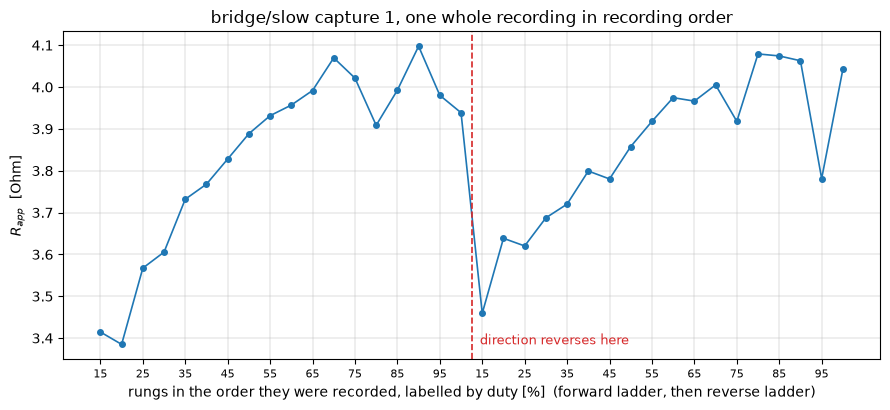

slope of R_app against capture index, averaged over duties: +0.00779 Ohm per capture, sd 0.01283
forward 100% rung reads 4.0215 Ohm, then the reverse ladder restarts at 3.5916 Ohm at 20%


,capture 1,capture 2,capture 3,capture 4,capture 5,forward half,"reverse half (later, hotter)",reverse - forward
duty_mag,,,,,,,,
15,3.4369,3.5402,3.4377,3.5026,3.5709,3.5199,3.4754,-0.0445
20,3.5117,3.4582,3.4670,3.6071,3.5009,3.4263,3.5916,0.1653
25,3.5937,3.5998,3.6696,3.6269,3.6595,3.5986,3.6612,0.0627
30,3.6464,3.6138,3.6543,3.7140,3.6921,3.6459,3.6824,0.0366
35,3.7260,3.7644,3.7226,3.8009,3.7961,3.7367,3.7872,0.0505
40,3.7835,3.7972,3.8098,3.8519,3.7668,3.8200,3.7837,-0.0363
45,3.8041,3.8612,3.8594,3.8760,3.8642,3.8777,3.8283,-0.0495
50,3.8730,3.8654,3.8970,3.9131,3.8981,3.9028,3.8758,-0.0270
55,3.9247,3.9421,3.8928,3.9445,3.9123,3.9450,3.9016,-0.0435


In [7]:
heat = pd.DataFrame({
    **{f"capture {c}": slow[slow["capture"] == c].groupby("duty_mag")["R_app_ohm"].mean()
       for c in sorted(slow["capture"].unique())},
    "forward half": slow[slow["dir"] > 0].groupby("duty_mag")["R_app_ohm"].mean(),
    "reverse half (later, hotter)": slow[slow["dir"] < 0].groupby("duty_mag")["R_app_ohm"].mean(),
})
heat["reverse - forward"] = heat["reverse half (later, hotter)"] - heat["forward half"]

# Slope of R_app against capture index at each duty. Captures are separated by a
# 150 s cooldown, so a cumulative thermal drift would show here too.
cap_slope = pd.Series({
    d: np.polyfit(g["capture"], g["R_app_ohm"], 1)[0]
    for d, g in slow.groupby("duty_mag")}, name="Ohm per capture")

fig, ax = plt.subplots(figsize=(9, 4.2))
one = slow[slow["capture"] == 1].sort_values(["dir", "duty_mag"], ascending=[False, True])
order = np.arange(len(one))
ax.plot(order, one["R_app_ohm"], "o-", ms=4, lw=1.2, color="tab:blue")
flip = int((one["dir"] > 0).sum())
ax.axvline(flip - 0.5, color="tab:red", lw=1.2, ls="--")
ax.text(flip - 0.3, one["R_app_ohm"].min(), " direction reverses here", color="tab:red", fontsize=9)
ax.set_xticks(order[::2])
ax.set_xticklabels([f"{d:.0f}" for d in one["duty_mag"]][::2], fontsize=8)
ax.set_xlabel("rungs in the order they were recorded, labelled by duty [%]  "
              "(forward ladder, then reverse ladder)")
ax.set_ylabel(r"$R_{app}$  [Ohm]")
ax.set_title("bridge/slow capture 1, one whole recording in recording order")
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

print(f"slope of R_app against capture index, averaged over duties: "
      f"{cap_slope.mean():+.5f} Ohm per capture, sd {cap_slope.std():.5f}")
print(f"forward 100% rung reads {heat.loc[100, 'forward half']:.4f} Ohm, then the "
      f"reverse ladder restarts at {heat.loc[20, 'reverse half (later, hotter)']:.4f} Ohm at 20%")
heat.round(4)

**What you are looking at.** One whole recording laid out in the order the rungs
were actually taken. The forward ladder climbs from 3.4 to 4.0 Ohm, then the
direction flips at the dashed line and the apparent resistance drops straight
back to where it started and climbs again. A warming winding cannot do that.

The capture-order slope is $+0.007 \pm 0.013$ Ohm per capture, which is noise,
and the captures have a 150 s cooldown between them anyway.

**Finding.** H4 is dead. The ladder resets at the direction change inside a
single recording and there is no trend across captures. Whatever else is true,
the motor is not measurably warming across a sweep.

One number in that table is worth flagging rather than smoothing over. At the
20% rung the reverse half reads 0.165 Ohm above the forward half, the largest
forward-to-reverse gap anywhere in the ladder. Above 40% the two halves agree to
under 0.05 Ohm. So an amplifier offset, which H2 predicted would show as a
direction asymmetry, is dead above 40% and not quite dead at the very bottom.
Section 8 argues that the bottom of the ladder has its own problem.

### 5.4 The sampling-phase story needs a $dt$ that is not constant

H6 says the crest current sample sits a fixed time off the center of the drive
window and therefore over-reads by $dt \cdot di/dt$. That is a constant error in
**amps**, not in volts, and $di/dt$ during the driven half collapses as the
current approaches its ceiling. So a fixed $dt$ predicts an offset in volts that
varies a lot across the ladder, and the fitted $V_0$ is nearly flat.

Turn it round and ask what $dt$ each rung would need.

In [8]:
L_REG = servo.measured["l_motor_measured"].value / 1e3      # H, bare-can registry value
R_REF = 4.196                                               # a working R for this diagnostic only

# The 15% rung is excluded here for the reason section 8 gives.
sl20 = slow[slow["duty_mag"] >= 20]
phase = sl20.groupby("duty_mag")[["i_win_A", "applied_V", "e_entry_V"]].mean()
# di/dt in the drive window: (rail - the aiding entry EMF - I*R) / L
phase["di/dt [A/s]"] = (7.45 + 0.70 - R_REF * phase["i_win_A"]) / L_REG
phase["offset needed [V]"] = phase["applied_V"] - R_REF * phase["i_win_A"]
phase["current error it implies [A]"] = -phase["offset needed [V]"] / R_REF
phase["dt a phase story needs [us]"] = (phase["current error it implies [A]"]
                                        / phase["di/dt [A/s]"] * 1e6)

o = phase["offset needed [V]"]
d = phase["dt a phase story needs [us]"]
print(f"the offset in VOLTS varies {o.std() / o.abs().mean() * 100:.1f}% across the ladder")
print(f"the dt a phase story needs varies {d.std() / d.abs().mean() * 100:.1f}%, "
      f"from {d.min():.1f} to {d.max():.1f} us")
print(f"half a PWM period is {PWM_HALF_US:.0f} us, and at 100% duty there is no ripple at all")
phase.round(4)

the offset in VOLTS varies 14.6% across the ladder
the dt a phase story needs varies 63.7%, from 5.4 to 30.9 us
half a PWM period is 25 us, and at 100% duty there is no ripple at all


,i_win_A,applied_V,e_entry_V,di/dt [A/s],offset needed [V],current error it implies [A],dt a phase story needs [us]
duty_mag,,,,,,,
20,0.4202,1.4729,-0.7146,12774.0676,-0.2901,0.0691,5.4114
25,0.5045,1.8308,-0.6848,12066.1951,-0.2861,0.0682,5.6512
30,0.5964,2.1847,-0.7045,11295.4001,-0.3176,0.0757,6.7007
35,0.6742,2.5357,-0.7104,10642.2125,-0.2932,0.0699,6.5651
40,0.7582,2.8822,-0.7225,9937.3191,-0.2992,0.0713,7.1746
45,0.8370,3.2246,-0.6870,9275.5311,-0.2876,0.0685,7.3896
50,0.9163,3.5637,-0.7052,8610.2978,-0.2812,0.0670,7.7825
55,0.9938,3.8987,-0.6907,7960.1151,-0.2712,0.0646,8.1209
60,1.0658,4.2316,-0.7210,7355.4730,-0.2406,0.0573,7.7963


**Finding.** H6 is dead twice over. It needs one $dt$ and the ladder demands
5.4 to 30.9 us, a swing of about 60%, where the offset in volts moves only about
15%. And at 100% duty it needs a non-zero error on a rung with no ripple for a
phase error to bite on. The offset is a constant number of volts, not a constant
number of amps.

### 5.5 Every rung opens with the shaft still moving

This is the big one, and it is a defect in how the captures were taken rather
than anything about the motor.

`sweep.rs` runs this sequence per rung. Brake to rest, torque off, **rest 1500
ms**, then **seek the start band at 15% duty**, then torque on and open the
burst. The rest happens *before* the seek, and nothing at all happens between
the seek finishing and the burst starting. So every rung opens with the shaft
still coasting from the seek, and because a forward rung's start band is at the
low end of travel, that coast is **backward**, against the rung about to be
driven.

I have since fixed the tool. `osc sweep` now takes `--settle-ms`, a brake and
hold after the seek with a default of 300 ms, so future captures will not carry
this. Every recording in the current datasets does, and the metadata proves it,
because these captures have no `settle_ms` key at all.

The burst opens a tick or two before the duty write lands, so sample 0 of every
rung is pre-drive. Bridge idle, shunt at its bias, terminals floating. That is a
free reading of whatever EMF the shaft carries in, and it costs nothing to take.

                      seek_duty_pct  rest_ms                  settle_ms  window_ms decay
experiment recording                                                                    
bridge     slow                  15     1500  ABSENT - predates the fix        150  slow
grid       sweep                 15     1500  ABSENT - predates the fix        150  slow

the terminal reading of -0.699 V through the Ke chain implies 2823 pot counts/s of backward motion,
and notebook 03 measures the 15% seek that caused it at about 3100 counts/s, which is 9.8% away
the three routes above span 0.699 to 0.747 V, 6.8% apart
the bridge/fast row is not one of the three and section 5.6.1 says why

subtracting the measured EMF rung by rung gives 5.10 Ohm at 20% duty falling to 4.43 at 100%,
a spread of 0.67 Ohm against the 0.56 Ohm of the original slide, and in the opposite direction


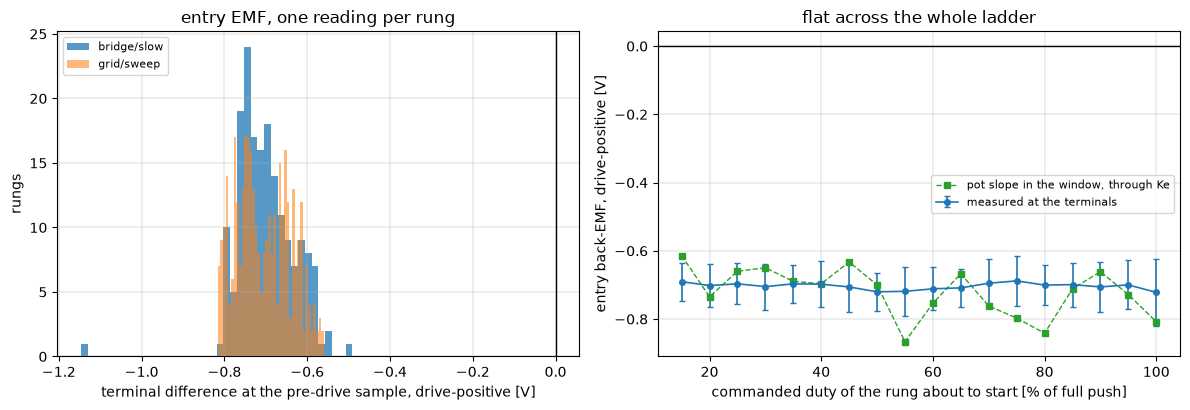

,value [V],sd [V],n
route,,,
"terminal difference at the pre-drive sample, bridge/slow",-0.6993,0.0713,180
"same, bridge/fast - NOT a fourth route, see section 5.6.1",-0.4878,0.3116,178
"terminal difference at the pre-drive sample, grid/sweep",-0.7056,0.0645,360
"pot slope in the fit window x registry Ke chain, bridge/slow",-0.7467,0.3291,180


In [9]:
import json

# The metadata is the proof that these captures predate the tool fix.
meta_rows = []
for exp, name in (("bridge", "slow"), ("grid", "sweep")):
    rec, = [r for r in ds.recordings(exp, "capture-1") if r.name == name]
    m = rec.meta
    meta_rows.append({"experiment": exp, "recording": name,
                      "seek_duty_pct": m["seek_duty_pct"], "rest_ms": m["rest_ms"],
                      "settle_ms": m.get("settle_ms", "ABSENT - predates the fix"),
                      "window_ms": m["window_ms"], "decay": m["decay"]})
print(pd.DataFrame(meta_rows).set_index(["experiment", "recording"]).to_string())

# Route 1: the terminal difference at the pre-drive sample of every rung.
# Route 2: the pot slope in the fit window, through the registry Ke chain.
pd.set_option("display.max_colwidth", 80)
emf = pd.DataFrame([
    {"route": "terminal difference at the pre-drive sample, bridge/slow",
     "value [V]": slow["e_entry_V"].mean(), "sd [V]": slow["e_entry_V"].std(), "n": len(slow)},
    {"route": "same, bridge/fast - NOT a fourth route, see section 5.6.1",
     "value [V]": fast["e_entry_V"].mean(), "sd [V]": fast["e_entry_V"].std(), "n": len(fast)},
    {"route": "terminal difference at the pre-drive sample, grid/sweep",
     "value [V]": grid["e_entry_V"].mean(), "sd [V]": grid["e_entry_V"].std(), "n": len(grid)},
    {"route": "pot slope in the fit window x registry Ke chain, bridge/slow",
     "value [V]": KE_POT * slow["spd_win_cps"].mean(),
     "sd [V]": KE_POT * slow["spd_win_cps"].std(), "n": len(slow)},
]).set_index("route")

# Route 3, a consistency check with no fitting in it at all: turn the measured
# terminal EMF back into pot counts per second through the same chain and compare
# it with the speed notebook 03 measured for the 15% seek that produced it.
NB03_SEEK_CPS = 3100.0
implied_cps = abs(slow["e_entry_V"].mean()) / KE_POT
# The fast row is dropped from the spread: section 5.6.1 shows it is a different
# population, not a disagreeing measurement of the same one.
spread = emf["value [V]"].abs().drop(index=[r for r in emf.index if "bridge/fast" in r])
print(f"\nthe terminal reading of {slow['e_entry_V'].mean():.3f} V through the Ke chain "
      f"implies {implied_cps:.0f} pot counts/s of backward motion,")
print(f"and notebook 03 measures the 15% seek that caused it at about "
      f"{NB03_SEEK_CPS:.0f} counts/s, which is "
      f"{(NB03_SEEK_CPS / implied_cps - 1) * 100:.1f}% away")
print(f"the three routes above span {spread.min():.3f} to {spread.max():.3f} V, "
      f"{(spread.max() / spread.min() - 1) * 100:.1f}% apart")
print("the bridge/fast row is not one of the three and section 5.6.1 says why")

# What happens if the measured EMF is taken at face value and subtracted rung by
# rung. If it were the whole story this would flatten R_app. It does the opposite.
b20 = both[both["duty_mag"] >= 20]
naive = b20.groupby("duty_mag")[["i_win_A", "applied_V", "e_entry_V", "spd_win_cps"]].mean()
naive["(DV - e)/i [Ohm]"] = (naive["applied_V"] - naive["e_entry_V"]) / naive["i_win_A"]
print(f"\nsubtracting the measured EMF rung by rung gives "
      f"{naive.loc[20, '(DV - e)/i [Ohm]']:.2f} Ohm at 20% duty falling to "
      f"{naive.loc[100, '(DV - e)/i [Ohm]']:.2f} at 100%,")
print(f"a spread of {naive['(DV - e)/i [Ohm]'].max() - naive['(DV - e)/i [Ohm]'].min():.2f} Ohm "
      f"against the {slide.loc[20:, 'R_app bridge [Ohm]'].max() - slide.loc[20:, 'R_app bridge [Ohm]'].min():.2f} "
      f"Ohm of the original slide, and in the opposite direction")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.hist(slow["e_entry_V"], bins=40, color="tab:blue", alpha=0.75, label="bridge/slow")
ax.hist(grid["e_entry_V"], bins=40, color="tab:orange", alpha=0.55, label="grid/sweep")
ax.axvline(0, color="k", lw=1.0)
ax.set_xlabel("terminal difference at the pre-drive sample, drive-positive [V]")
ax.set_ylabel("rungs")
ax.set_title("entry EMF, one reading per rung")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)

ax = axes[1]
t = both.groupby("duty_mag")["e_entry_V"].agg(["mean", "std"])
ax.errorbar(t.index, t["mean"], yerr=t["std"], marker="o", ms=4, lw=1.2,
            capsize=2, color="tab:blue", label="measured at the terminals")
tp = both.groupby("duty_mag")["e_pot_win_V"].mean()
ax.plot(tp.index, tp, "s--", ms=4, lw=1.0, color="tab:green",
        label="pot slope in the window, through Ke")
ax.axhline(0, color="k", lw=1.0)
ax.set_xlabel("commanded duty of the rung about to start [% of full push]")
ax.set_ylabel("entry back-EMF, drive-positive [V]")
ax.set_title("flat across the whole ladder")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

emf.round(4)

**What you are looking at.** Left, the distribution of the pre-drive terminal
reading over every rung of both experiments. It sits at about $-0.70$ V and it
never crosses zero. Right, the same reading averaged per duty, with the pot
route through the registry Ke chain plotted alongside. Both are flat across the
ladder, from $-0.665$ to $-0.736$ V, with no trend in duty.

Three independent routes land within about 7%. The terminals read $-0.699$ V
over 180 bridge rungs and $-0.706$ V over 360 grid rungs, which is a 0.9%
agreement between two experiments. The pot slope through the Ke chain gives
$-0.747$ V, 6.8% away, and part of that gap is the disputed pot scale, which is
itself worth 3.3%. Running the terminal value backward through the same chain
implies about 2820 pot counts per second, where notebook 03 measured the 15%
seek that caused it at about 3100, a further 10%.

That last 10% is looser than I would like and I am quoting it as it came out.
The report this section is built on claimed 3% for the whole set, and I do not
get that. The two terminal routes are the tight pair, and both of the routes
that pass through the gear chain and the pot scale are 7 to 10% away from them.
For sizing an EMF that is fine. For anything else it would not be.

The sign is opposite the drive in **both** directions, which is what a seek that
always parks at the far wall produces, and it is why this is a schedule artifact
and not a bias.

**Finding.** H3 is real and large. The entry EMF is the dominant term inside
$V_0$. But it does not explain the slide on its own, and taking it at face value
makes things worse. Subtracting the measured $-0.70$ V rung by rung gives
$(DV - e)/i$ running 5.10 Ohm at 20% duty down to 4.43 at 100%, which reverses
the slide and makes it bigger than the one it was supposed to remove. The EMF's
whole effect is a constant, and a constant is what $V_0$ already absorbs.

Since $V_0$ is $-0.33$ V while the measured EMF is $-0.70$ V, there must also be
about $+0.37$ V of fixed *opposing* drop in there. The terminal taps sit on the
bridge outputs, so bridge $R_{ds}$ is outside this measurement, and the natural
candidate is brush contact voltage, which is conventionally modelled as exactly
this, a constant number of volts. **I cannot separate the two here.** Both are
constant across the ladder, so they are one parameter, and "the $+0.37$ V is
brush drop" has no discriminating experiment in this dataset. That makes it a
story, not a hypothesis, and I am labelling it as one. Section 10 is where it
gets an experiment.

#### 5.5.1 Sliding the window later

One corroboration is available for free. As the drive turns the shaft round, the
backward speed decays, so the aiding EMF should shrink. Run the same estimator
with the fit window slid later and watch what happens to the intercept.

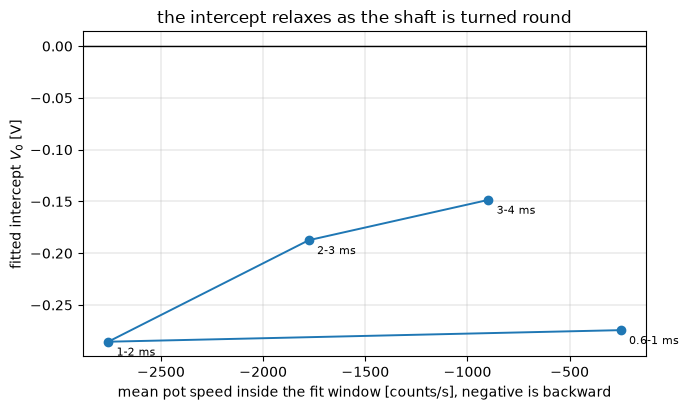

,R_app 20-30% [Ohm],R_app 70-100% [Ohm],fitted R [Ohm],fitted V0 [V],mean speed [counts/s]
window,,,,,
0.6-1 ms,3.5768,3.9764,4.1573,-0.2743,-250.0000
1-2 ms,3.6143,4.0611,4.2463,-0.2855,-2757.8112
2-3 ms,3.8411,4.1822,4.3050,-0.1874,-1776.6917
3-4 ms,4.0126,4.3488,4.4491,-0.1485,-897.8279
anchor 0.6-2 ms,3.6010,4.0334,4.2255,-0.2893,-3013.9573


In [10]:
wins = list(LADDER) + ["anchor 0.6-2 ms"]
rows = []
for w in wins:
    ic = "i_win_A" if w.startswith("anchor") else f"i_{w}"
    rc = "R_app_ohm" if w.startswith("anchor") else f"R_{w}"
    sc = "spd_win_cps" if w.startswith("anchor") else f"spd_{w}"
    i = slow[ic].to_numpy()
    dv = slow[rc].to_numpy() * i             # applied volts in that window
    R, V0 = np.polyfit(i, dv, 1)
    by = slow.groupby("duty_mag")[rc].mean()
    rows.append({"window": w, "R_app 20-30% [Ohm]": by.loc[[20, 25, 30]].mean(),
                 "R_app 70-100% [Ohm]": by.loc[[70, 80, 90, 100]].mean(),
                 "fitted R [Ohm]": R, "fitted V0 [V]": V0,
                 "mean speed [counts/s]": slow[sc].mean()})
wl = pd.DataFrame(rows).set_index("window")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(wl["mean speed [counts/s]"][:4], wl["fitted V0 [V]"][:4], "o-", ms=6,
        lw=1.4, color="tab:blue")
for w, r in wl.iloc[:4].iterrows():
    ax.annotate(w, (r["mean speed [counts/s]"], r["fitted V0 [V]"]),
                textcoords="offset points", xytext=(6, -10), fontsize=8)
ax.axhline(0, color="k", lw=1.0)
ax.set_xlabel("mean pot speed inside the fit window [counts/s], negative is backward")
ax.set_ylabel("fitted intercept $V_0$ [V]")
ax.set_title("the intercept relaxes as the shaft is turned round")
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

wl.round(4)

**What you are looking at.** The fitted intercept against the mean backward
speed inside the window that produced it, for four windows sliding from 0.6 ms
to 4 ms after turn-on. As the drive brakes the shaft and turns it round, the
backward speed decays from about $-2760$ to $-900$ counts per second and the
intercept relaxes from $-0.29$ V toward $-0.15$ V, which is the direction of the
$+0.37$ V fixed term.

Direction and ordering match. **The two do not track one for one, and I do not
know why.** The later windows also pick up a growing forward EMF that pushes the
other way, and their pot slopes are short and noisy. So this is corroboration
and not proof, and section 13 keeps it open.

The other thing this table shows is the price of the entry EMF. Fitting at 3 to
4 ms instead of the anchor window moves $R$ from 4.23 to 4.45 Ohm. Anything
fitted at a rung onset on these captures has this defect inside it, which is the
reason section 7 cannot pin the inductance.

### 5.6 Slow decay against fast decay

H1 and H2 differ on what should happen when the off-state path changes and the
resistance does not. Under slow decay the off state shorts the winding through
the low side. Under fast decay it opens the bridge entirely and the current
freewheels through the body diodes against the rail. The driven half is the same
bridge state in both.

There is one instrument limit to state before the table, because it is not
small. The telemetry mask on these captures streams peak-scan terminal taps
only, and under fast decay the peak scan is the **coast** half. So the fast
recordings carry a driven-half current, from the trough shunt, and no
driven-half voltage at all. The applied volts below are taken from the **same
capture's slow recording** at the same duty and direction. That substitution is
stated, not hidden, and it is exact only at 100% duty where the two files
command an identical bridge state.

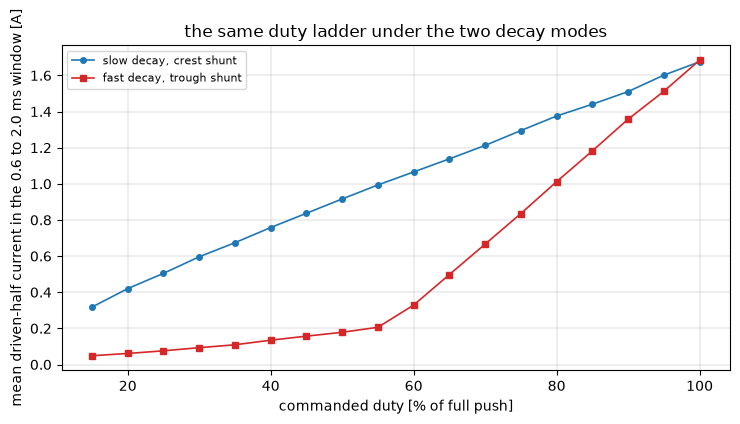

the same line fitted to the fast data: R = 2.8947 Ohm, V0 = +2.3994 V, rms residual 0.6430 V
per-duty residual span 2.3311 V - a structurally wrong model

at 100% duty the two modes agree on current to 0.5% and on R_app to 0.5%


,R slow [Ohm],sd slow,"R fast, substituted rail [Ohm]",sd fast,i slow [A],i fast [A],i fast / i slow
duty_mag,,,,,,,
15,3.4977,0.0738,22.8760,0.7580,0.3178,0.0487,0.1531
20,3.5090,0.1120,24.1851,1.6890,0.4202,0.0612,0.1456
25,3.6299,0.0599,24.2733,1.5069,0.5045,0.0757,0.1501
30,3.6641,0.0472,23.5031,1.2318,0.5964,0.0932,0.1563
35,3.7620,0.0535,23.3106,1.3255,0.6742,0.1091,0.1619
40,3.8018,0.0449,21.4546,1.1109,0.7582,0.1346,0.1776
45,3.8530,0.0517,20.5520,0.4077,0.8370,0.1569,0.1875
50,3.8893,0.0281,19.9801,0.2633,0.9163,0.1784,0.1947
55,3.9233,0.0391,18.9280,0.1915,0.9938,0.2060,0.2073


In [11]:
# Pair each fast rung with the applied volts its own capture measured at the same
# duty and direction under slow decay. See the caveat above.
rail = slow.groupby(["capture", "duty_mag", "dir"])["v_win_V"].mean().rename("v_rail_V")
fast2 = fast.join(rail, on=["capture", "duty_mag", "dir"])
fast2["applied_sub_V"] = fast2["duty_mag"] / 100.0 * fast2["v_rail_V"]
fast2["R_app_sub"] = fast2["applied_sub_V"] / fast2["i_win_A"]

decay = pd.DataFrame({
    "R slow [Ohm]": slow.groupby("duty_mag")["R_app_ohm"].mean(),
    "sd slow": slow.groupby("duty_mag")["R_app_ohm"].std(),
    "R fast, substituted rail [Ohm]": fast2.groupby("duty_mag")["R_app_sub"].mean(),
    "sd fast": fast2.groupby("duty_mag")["R_app_sub"].std(),
    "i slow [A]": slow.groupby("duty_mag")["i_win_A"].mean(),
    "i fast [A]": fast.groupby("duty_mag")["i_win_A"].mean(),
})
decay["i fast / i slow"] = decay["i fast [A]"] / decay["i slow [A]"]

Rf, V0f = np.polyfit(fast2["i_win_A"], fast2["applied_sub_V"], 1)
resf = fast2["applied_sub_V"] - (Rf * fast2["i_win_A"] + V0f)
byf = pd.Series(resf.to_numpy()).groupby(fast2["duty_mag"].to_numpy()).mean()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(decay.index, decay["i slow [A]"], "o-", ms=4, lw=1.2, color="tab:blue",
        label="slow decay, crest shunt")
ax.plot(decay.index, decay["i fast [A]"], "s-", ms=4, lw=1.2, color="tab:red",
        label="fast decay, trough shunt")
ax.set_xlabel("commanded duty [% of full push]")
ax.set_ylabel("mean driven-half current in the 0.6 to 2.0 ms window [A]")
ax.set_title("the same duty ladder under the two decay modes")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"the same line fitted to the fast data: R = {Rf:.4f} Ohm, V0 = {V0f:+.4f} V, "
      f"rms residual {np.sqrt((resf ** 2).mean()):.4f} V")
print(f"per-duty residual span {byf.max() - byf.min():.4f} V - a structurally wrong model")
print(f"\nat 100% duty the two modes agree on current to "
      f"{abs(decay.loc[100, 'i fast / i slow'] - 1) * 100:.1f}% and on R_app to "
      f"{abs(decay.loc[100, 'R fast, substituted rail [Ohm]'] / decay.loc[100, 'R slow [Ohm]'] - 1) * 100:.1f}%")
decay.round(4)

**What you are looking at.** The driven-half current against duty under the two
decay modes. Under slow decay it is a clean line. Under fast decay it collapses
to about 15% of the slow value at the bottom of the ladder and only catches up
above about 55% duty, where the two curves meet.

That collapse is the expected physics, not a surprise. Under fast decay the off
state applies roughly minus the rail across the winding instead of a short, so
$D V_{rail}$ is nowhere near the mean winding voltage, and below about 55% duty
the winding goes into discontinuous conduction and the current dies inside every
period. The line fitted to the fast data is a structurally wrong model, which is
why the $R$ and $V_0$ printed above mean nothing, and why its residual is eight
times the slow-decay one with a per-duty span of over 2 V.

**The 100% control is the useful row.** At full duty both files command the same
static bridge state, and they agree to 0.5% on the current and 0.5% on
$R_{app}$. So the two recordings are measuring the same motor and the difference
below 100% is entirely the off-state path.

**Finding.** H2 survives as one of the two things inside $V_0$. A fixed drop
that lives in the driven half is unaffected by everything in this section, and
about $+0.37$ V of one is needed. The amplifier-offset flavour of H2 is dead,
because forward and reverse agree to under 0.05 Ohm above 40% duty and the
current bias is subtracted per recording from that recording's own baseline.

This discriminator is weaker than I wanted it to be, because of the terminal-tap
limit at the top of the section. Section 11 records what would fix it.

#### 5.6.1 The fast recordings prove the entry EMF the other way round

Something turned up here that I did not go looking for. The pre-drive terminal
reading of section 5.5 is $-0.70$ V on every slow rung. On the fast recordings
it is $-0.70$ V from 45% duty up and **exactly zero** below 35%.

The entry EMF exists because the seek before each rung leaves the shaft
coasting. If the previous rung never moved the shaft out of the start band, the
seek has nothing to do and never drives, so there is no coast and no EMF. Under
fast decay below about 35% duty the rungs make no net motion at all, which is
the discontinuous conduction the table above already showed. So the artifact
should switch itself off exactly there, and it does.

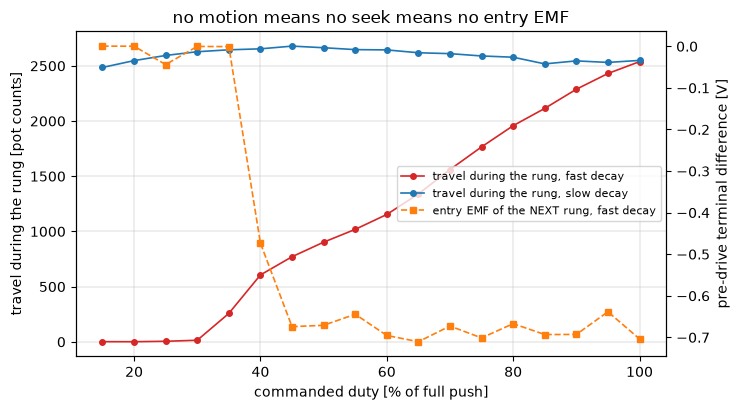

,"travel, slow [pot counts]","travel, fast [pot counts]","entry EMF, slow [V]","entry EMF, fast [V]","sd of entry EMF, fast"
duty_mag,,,,,
15,2485.4,1.7,-0.6648,0.0005,0.0023
20,2547.3,1.2,-0.7146,0.0002,0.0027
25,2594.1,5.2,-0.6848,-0.0439,0.1371
30,2627.8,14.5,-0.7045,-0.0002,0.0027
35,2645.3,257.7,-0.7104,-0.0007,0.0029
40,2654.0,605.9,-0.7225,-0.4734,0.3308
45,2678.7,770.9,-0.6870,-0.6742,0.0558
50,2664.1,902.8,-0.7052,-0.6709,0.0767
55,2647.0,1018.8,-0.6907,-0.6443,0.0635


In [12]:
# Travel per rung, measured straight off the pot, and the pre-drive terminal
# reading of the same rungs. The two have to switch together if the explanation
# above is right.
def travel_rows(dataset, experiment, name):
    out = []
    for cap in dataset.captures(experiment):
        rec, = [r for r in dataset.recordings(experiment, cap) if r.name == name]
        df, const, _ = prep(rec)
        for sid, seg in df.groupby("seg"):
            d = float(seg["duty_pct"].iloc[0])
            if sid == 0 or abs(d) < MIN_DUTY:
                continue
            p = seg["pos"].to_numpy()
            v = np.sign(d) * board.diff_v(seg["vmotor_a"].to_numpy() - const["vb"],
                                          seg["vmotor_b"].to_numpy() - const["vb_b"])
            out.append({"duty_mag": abs(round(d)), "travel_counts": abs(p[-1] - p[0]),
                        "e_entry_V": float(v[0])})
    return pd.DataFrame(out)

tr_slow = travel_rows(ds, "bridge", "slow")
tr_fast = travel_rows(ds, "bridge", "fast")
sw61 = pd.DataFrame({
    "travel, slow [pot counts]": tr_slow.groupby("duty_mag")["travel_counts"].mean(),
    "travel, fast [pot counts]": tr_fast.groupby("duty_mag")["travel_counts"].mean(),
    "entry EMF, slow [V]": tr_slow.groupby("duty_mag")["e_entry_V"].mean(),
    "entry EMF, fast [V]": tr_fast.groupby("duty_mag")["e_entry_V"].mean(),
    "sd of entry EMF, fast": tr_fast.groupby("duty_mag")["e_entry_V"].std(),
})

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax2 = ax.twinx()
ax.plot(sw61.index, sw61["travel, fast [pot counts]"], "o-", ms=4, lw=1.2,
        color="tab:red", label="travel during the rung, fast decay")
ax.plot(sw61.index, sw61["travel, slow [pot counts]"], "o-", ms=4, lw=1.2,
        color="tab:blue", label="travel during the rung, slow decay")
ax2.plot(sw61.index, sw61["entry EMF, fast [V]"], "s--", ms=4, lw=1.2,
         color="tab:orange", label="entry EMF of the NEXT rung, fast decay")
ax.set_xlabel("commanded duty [% of full push]")
ax.set_ylabel("travel during the rung [pot counts]")
ax2.set_ylabel("pre-drive terminal difference [V]")
ax.set_title("no motion means no seek means no entry EMF")
ax.grid(True, lw=0.3)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
plt.tight_layout()
plt.show()

sw61.round(4)

**What you are looking at.** Travel per rung against duty for both decay modes
on the left axis, and the pre-drive terminal reading on the right. Under slow
decay every rung covers about 2600 pot counts and every rung opens at $-0.70$ V.
Under fast decay the 15 to 30% rungs travel 1 to 15 counts, which is nothing,
and those are exactly the rungs whose entry EMF reads zero. The switchover
happens over 35 to 40% duty in both quantities at once.

That is a fourth independent route to the same conclusion, and it is the one I
like best, because it does not measure the EMF at all. It just shows the
artifact appearing and disappearing with the thing that is supposed to cause it.

## 6. What $R$ and $V_0$ actually are

Every alternative is now either dead or accounted for. Here are the two numbers,
with the spread that matters more than the nominal.

A single pooled fit would hide how much the answer moves between captures, so
instead I fit the line separately in every independent subset. One
(experiment, capture, direction) group is 17 rungs from a single ladder pass,
and there are 30 such groups across two experiments and 15 captures.

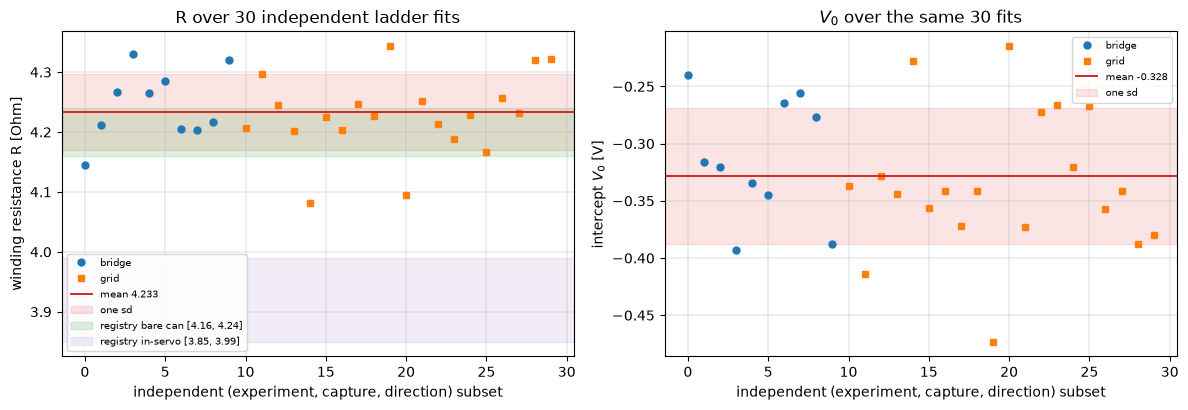

R   mean 4.2334 Ohm   sd 0.0634   range 4.0812 to 4.3434   n 30
V0  mean -0.3283 V     sd 0.0596   range -0.4732 to -0.2148   n 30

registry r_motor_measured: 4.2 [4.16, 4.24] Ohm - bringup isns-diff run28
registry r_winding_measured: 3.91 [3.85, 3.99] Ohm - nb02 part 2, locked-rotor ladder on 2S

R under three different treatments of the back-EMF, per-duty means, 20 to 100%:
  EMF ignored, so V0 absorbs it          R = 4.2398 Ohm   remaining offset = -0.3355 V
  EMF subtracted at its pre-drive value  R = 4.2429 Ohm   remaining offset = +0.3654 V
  EMF from the pot speed in the window   R = 4.3098 Ohm   remaining offset = +0.3160 V


,experiment,capture,dir,n rungs,R [Ohm],V0 [V],entry EMF [V]
0,bridge,1,-1,17,4.1457,-0.2402,-0.6695
1,bridge,1,1,17,4.2110,-0.3159,-0.7380
2,bridge,2,-1,17,4.2663,-0.3205,-0.7219
3,bridge,2,1,17,4.3306,-0.3933,-0.7389
4,bridge,3,-1,17,4.2659,-0.3341,-0.6752
5,bridge,3,1,17,4.2858,-0.3447,-0.7157
6,bridge,4,-1,17,4.2042,-0.2642,-0.6446
7,bridge,4,1,17,4.2033,-0.2555,-0.7149
8,bridge,5,-1,17,4.2165,-0.2764,-0.6687
9,bridge,5,1,17,4.3206,-0.3881,-0.7263


In [13]:
b20 = both[both["duty_mag"] >= 20]          # the 15% rung is excluded, see section 8

subs = []
for (exp, cap, dr), g in b20.groupby(["experiment", "capture", "dir"]):
    R, V0 = np.polyfit(g["i_win_A"], g["applied_V"], 1)
    subs.append({"experiment": exp, "capture": cap, "dir": dr, "n rungs": len(g),
                 "R [Ohm]": R, "V0 [V]": V0, "entry EMF [V]": g["e_entry_V"].mean()})
subs = pd.DataFrame(subs)

R_M, R_SD = subs["R [Ohm]"].mean(), subs["R [Ohm]"].std()
V_M, V_SD = subs["V0 [V]"].mean(), subs["V0 [V]"].std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col, reg, lab in (
        (axes[0], "R [Ohm]", servo.measured["r_motor_measured"], "winding resistance R [Ohm]"),
        (axes[1], "V0 [V]", None, "intercept $V_0$ [V]")):
    for exp, c, m in (("bridge", "tab:blue", "o"), ("grid", "tab:orange", "s")):
        g = subs[subs["experiment"] == exp]
        ax.plot(np.arange(len(g)) + (0 if exp == "bridge" else len(subs) - len(g)),
                g[col], m, ms=5, color=c, label=exp)
    ax.axhline(subs[col].mean(), color="tab:red", lw=1.4,
               label=f"mean {subs[col].mean():.3f}")
    ax.axhspan(subs[col].mean() - subs[col].std(), subs[col].mean() + subs[col].std(),
               color="tab:red", alpha=0.12, label="one sd")
    if reg is not None:
        ax.axhspan(reg.lo, reg.hi, color="tab:green", alpha=0.15,
                   label=f"registry bare can [{reg.lo}, {reg.hi}]")
        rw = servo.measured["r_winding_measured"]
        ax.axhspan(rw.lo, rw.hi, color="tab:purple", alpha=0.12,
                   label=f"registry in-servo [{rw.lo}, {rw.hi}]")
    ax.set_xlabel("independent (experiment, capture, direction) subset")
    ax.set_ylabel(lab)
    ax.grid(True, lw=0.3)
    ax.legend(fontsize=7.5)
axes[0].set_title("R over 30 independent ladder fits")
axes[1].set_title("$V_0$ over the same 30 fits")
plt.tight_layout()
plt.show()

print(f"R   mean {R_M:.4f} Ohm   sd {R_SD:.4f}   range {subs['R [Ohm]'].min():.4f} "
      f"to {subs['R [Ohm]'].max():.4f}   n {len(subs)}")
print(f"V0  mean {V_M:+.4f} V     sd {V_SD:.4f}   range {subs['V0 [V]'].min():+.4f} "
      f"to {subs['V0 [V]'].max():+.4f}   n {len(subs)}")
print()
for k in ("r_motor_measured", "r_winding_measured"):
    m = servo.measured[k]
    print(f"registry {k}: {m.value} [{m.lo}, {m.hi}] {m.unit} - {m.source}")

# How much does R move if the back-EMF is handled differently? R is only as firm
# as the assumption that the entry EMF does not itself slide with duty.
print("\nR under three different treatments of the back-EMF, per-duty means, 20 to 100%:")
tt = b20.groupby("duty_mag")[["i_win_A", "applied_V", "e_entry_V", "spd_win_cps"]].mean()
for tag, e in (("EMF ignored, so V0 absorbs it", 0 * tt["i_win_A"]),
               ("EMF subtracted at its pre-drive value", tt["e_entry_V"]),
               ("EMF from the pot speed in the window", KE_POT * tt["spd_win_cps"])):
    R, V0 = np.polyfit(tt["i_win_A"], tt["applied_V"] - e, 1)
    print(f"  {tag:38s} R = {R:.4f} Ohm   remaining offset = {V0:+.4f} V")

subs.round(4)

**What you are looking at.** Each dot is one complete ladder fit over 17 rungs
of a single pass. Left, the fitted $R$, with the two registry entries shaded
behind it. Right, the fitted $V_0$ over the same 30 fits. The red band is one
standard deviation of the 30.

**Findings.**

- $R = 4.233$ Ohm, bracket 4.081 to 4.343, over 30 independent fits, sd 0.063.
- $V_0 = -0.328$ V, bracket $-0.473$ to $-0.215$, sd 0.060. Negative means it
  aids the drive.
- Nothing about the winding resistance depends on duty, on decay mode, on
  direction, or on capture order.

**The registry needs correcting, and this notebook does not own that entry.**
(Written before part 2. Part 2 then measured 3.91 Ohm with the rotor locked,
and that is what the registry now carries. The paragraph below is left as it was.)
`r_winding_measured` currently carries 4.5 Ohm with a bracket of [4.3, 4.8],
sourced to notebook 03's full-duty onset anchor. That is precisely the one-point
ratio this notebook takes apart, evaluated at the single duty where the bias is
smallest, and it still reads high. The value it should carry is **4.23 Ohm with
a bracket of [4.08, 4.34]**, sourced to this notebook's ladder fit, with a note
that the fit window is 0.6 to 2.0 ms after turn-on on a free shaft and that the
intercept absorbs an entry EMF the capture tool no longer produces.

That new value overlaps the bare-can `r_motor_measured` of 4.2 [4.16, 4.24],
which is a different measurement on a different can and did not have to agree
with anything.

**How firm is it.** $R$ is only as firm as the assumption that the entry EMF
does not itself slide with duty. Within this measurement it does not, $-0.665$ to
$-0.736$ V with no trend, and the table printed under the plot shows what
happens when the EMF is handled three different ways. Ignoring it entirely gives
4.240 Ohm, subtracting it at its measured pre-drive value gives 4.243, and
taking it from the pot speed in the window gives 4.310. So $R$ does not move
below 4.24 under any treatment this data supports, and the honest bracket is the
[4.08, 4.34] the 30 subsets give.

That third row is worth a second look on its own. Subtracting the measured
$-0.70$ V leaves a remaining offset of **$+0.365$ V**, which is the fixed
opposing drop of section 5.5 arriving by a different arithmetic route. It is the
same number, not an independent measurement, because it is the same two
quantities rearranged. But it is the quantity part 2 predicts, so it is worth
having it printed rather than done in my head.

## 7. Inductance, and why it does not come out clean

### 7.1 The method

With $R$ in hand, $L$ should follow from the shape of the current rise at the
start of a rung. The cycle-average electrical equation under slow decay is

$$L \frac{di}{dt} = D \, v(t) - R \, i(t) - V_0$$

where $v(t)$ is the measured terminal difference at that sample, so rail droop
under the inrush is handled rather than assumed away, and $V_0$ carries the
entry EMF plus whatever fixed drop lives with it.

A textbook exponential fit would work, but with $\tau = L/R$ near 125 us and
samples 50 us apart there are only about a dozen points across five time
constants, and the drive lands somewhere inside a PWM period so the time origin
is uncertain by up to one whole sample. Instead I integrate the equation, which
turns it into a straight line through the origin and is far less sensitive to
noise on any one sample:

$$L \,\big(i_k - i_0\big) = \int_{t_0}^{t_k} \big(D v - R i - V_0\big)\,dt$$

Regress the left side against the right and the slope is $L$. The integral is a
trapezoid over the crest samples. I start one sample after the first driven
sample, because that first sample can be a partial period.

540 rung onsets, 30 per duty
R used in the fit: 4.2334 Ohm from section 6
tau at the registry L of 0.50 mH would be 118 us, so five tau spans 11.8 samples at 50 us


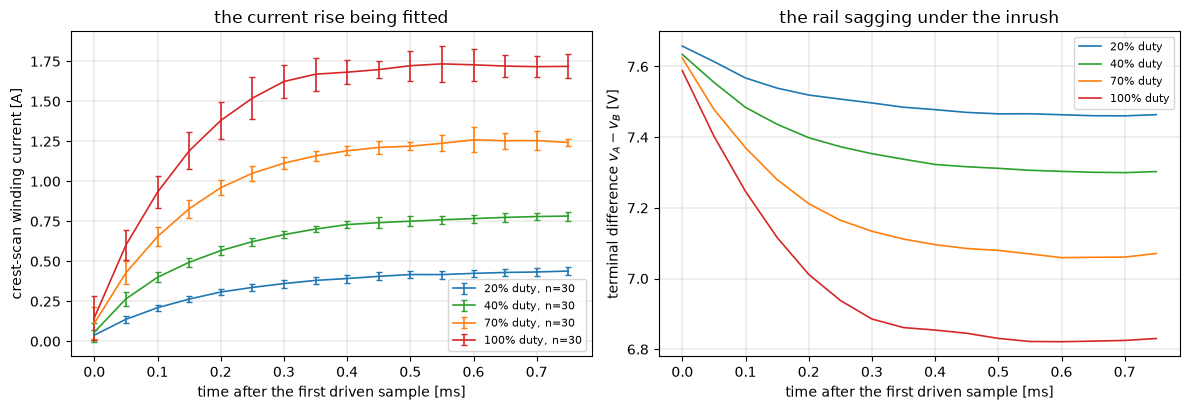

In [14]:
R_FIT = R_M          # the ladder R from section 6

def onset_traces(dataset, experiment, name, nkeep=40):
    """Raw onset traces, one per rung: terminal volts and current from turn-on."""
    out = []
    for cap in dataset.captures(experiment):
        rec, = [r for r in dataset.recordings(experiment, cap) if r.name == name]
        df, const, _ = prep(rec)
        for sid, seg in df.groupby("seg"):
            d = float(seg["duty_pct"].iloc[0])
            if sid == 0 or abs(d) < MIN_DUTY:
                continue
            sgn = int(np.sign(d))
            v = sgn * board.diff_v(seg["vmotor_a"].to_numpy() - const["vb"],
                                   seg["vmotor_b"].to_numpy() - const["vb_b"])
            i = (seg["current_raw"].to_numpy() - const["bias"]) * board.a_per_count
            hits = np.flatnonzero(v > RAIL_ON_V)
            if len(hits) == 0 or hits[0] < 1:
                continue
            on = int(hits[0])
            if on + nkeep >= len(seg):
                continue
            out.append({"capture": int(cap.split("-")[1]), "duty": abs(round(d)),
                        "dir": sgn, "v": v[on:on + nkeep].copy(),
                        "i": i[on:on + nkeep].copy()})
    return out

traces = onset_traces(ds, "bridge", "slow") + onset_traces(ds, "grid", "sweep")

def fit_L(rows, V0, n=12, skip=1, R=R_FIT):
    """Integral-form L, one value per rung. n samples of rise, starting `skip`
    samples after the first driven sample."""
    Ls, duty = [], []
    for r in rows:
        D = r["duty"] / 100.0
        v = r["v"][skip:skip + n]
        i = r["i"][skip:skip + n]
        drive = D * v - R * i - V0                      # volts across the inductance
        S = np.concatenate([[0.0], np.cumsum((drive[1:] + drive[:-1]) / 2 * DT)])
        y = i - i[0]
        k = float(np.dot(S, y) / np.dot(S, S))          # slope of y against S is 1/L
        if k > 0:
            Ls.append(1.0 / k)
            duty.append(r["duty"])
    return np.array(Ls), np.array(duty)

print(f"{len(traces)} rung onsets, {len(traces) // 18} per duty")
print(f"R used in the fit: {R_FIT:.4f} Ohm from section 6")
print(f"tau at the registry L of {L_REG * 1e3:.2f} mH would be "
      f"{L_REG / R_FIT * 1e6:.0f} us, so five tau spans "
      f"{5 * L_REG / R_FIT / DT:.1f} samples at {DT * 1e6:.0f} us")

# The ensemble onset at four duties, to show what is being fitted.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
tms = np.arange(16) * DT * 1e3
for d, c in ((20, "tab:blue"), (40, "tab:green"), (70, "tab:orange"), (100, "tab:red")):
    sel = [t for t in traces if t["duty"] == d]
    I = np.array([t["i"][:16] for t in sel])
    V = np.array([t["v"][:16] for t in sel])
    axes[0].errorbar(tms, I.mean(0), yerr=I.std(0), lw=1.2, capsize=2, color=c,
                     label=f"{d}% duty, n={len(sel)}")
    axes[1].plot(tms, V.mean(0), lw=1.2, color=c, label=f"{d}% duty")
axes[0].set_xlabel("time after the first driven sample [ms]")
axes[0].set_ylabel("crest-scan winding current [A]")
axes[0].set_title("the current rise being fitted")
axes[1].set_xlabel("time after the first driven sample [ms]")
axes[1].set_ylabel("terminal difference $v_A - v_B$ [V]")
axes[1].set_title("the rail sagging under the inrush")
for ax in axes:
    ax.grid(True, lw=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What you are looking at.** Left, the ensemble current rise at four duties,
error bars the spread across all 30 rungs at that duty. The scatter on the very
first sample is much larger than on the rest, which is the time-origin problem.
The drive lands somewhere inside a PWM period, so the first driven sample
catches a random fraction of it. That is why the fit starts one sample later.
Right, the terminal difference over the same window. At 100% duty the rail sags
from 7.59 to 6.82 V under a 1.7 A inrush, about 10%, and the fit uses the
measured value per sample rather than a nominal rail.

### 7.2 The answer moves with what you assume about $V_0$

$L$ is not measured independently of the offset. That is the whole problem, so
here it is head on.

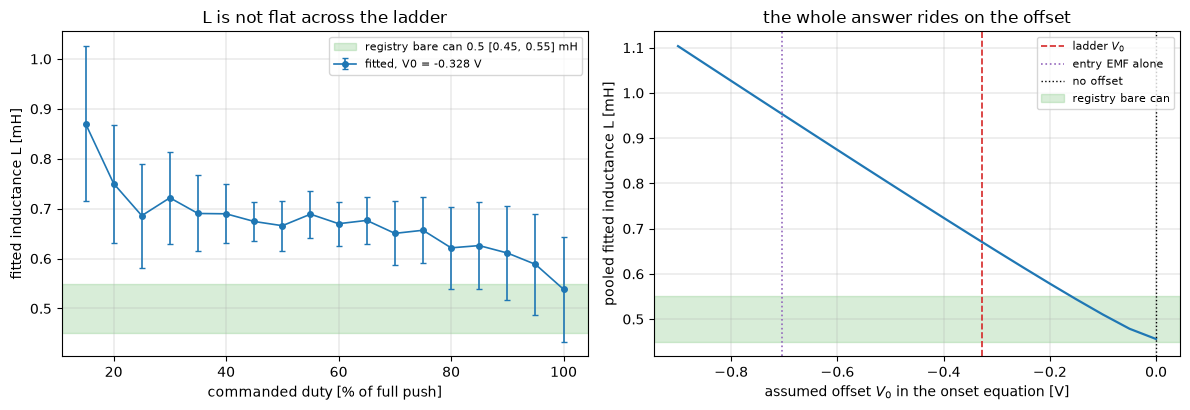

                                         L mean [mH]  L median [mH]  sd [mH]     CV %  n rungs  slope vs duty [mH per 100%]
assumed offset                                                                                                             
V0 from the section 6 ladder (-0.328 V)       0.6709         0.6699   0.1077  16.0563      540                      -0.2283
V0 = 0, what a naive onset fit assumes        0.4559         0.4581   0.1084  23.7836      540                       0.1273
the entry EMF alone (-0.704 V)                0.9528         0.9055   0.2463  25.8469      540                      -0.7840

L duty by duty, at the section 6 offset:
            mean     std     min     max  size
duty_mag                                      
15        0.8705  0.1551  0.6117  1.1777    30
20        0.7504  0.1182  0.5541  1.0094    30
25        0.6860  0.1040  0.5221  0.8928    30
30        0.7218  0.0925  0.5719  0.9440    30
35        0.6904  0.0762  0.5662  0.8789    30
40       

In [15]:
V0_ENTRY = float(both["e_entry_V"].mean())          # the measured entry EMF alone

variants = [
    (V_M, f"V0 from the section 6 ladder ({V_M:+.3f} V)"),
    (0.0, "V0 = 0, what a naive onset fit assumes"),
    (V0_ENTRY, f"the entry EMF alone ({V0_ENTRY:+.3f} V)"),
]
rows = []
for V0, lab in variants:
    L, du = fit_L(traces, V0)
    rows.append({"assumed offset": lab, "L mean [mH]": L.mean() * 1e3,
                 "L median [mH]": np.median(L) * 1e3, "sd [mH]": L.std() * 1e3,
                 "CV %": L.std() / L.mean() * 100, "n rungs": len(L),
                 "slope vs duty [mH per 100%]": np.polyfit(du, L, 1)[0] * 1e3 * 100})
sens = pd.DataFrame(rows).set_index("assumed offset")

# How L reads duty by duty, at the ladder offset.
L_main, du_main = fit_L(traces, V_M)
per_duty = pd.DataFrame({"duty_mag": du_main, "L_mH": L_main * 1e3})
pd_tab = per_duty.groupby("duty_mag")["L_mH"].agg(["mean", "std", "min", "max", "size"])

# A sweep of the assumed offset, to show the sensitivity as a slope.
scan = []
for V0 in np.arange(-0.9, 0.05, 0.05):
    L, du = fit_L(traces, float(V0))
    scan.append({"V0": V0, "L_mH": L.mean() * 1e3,
                 "slope_vs_duty": np.polyfit(du, L, 1)[0] * 1e3 * 100})
scan = pd.DataFrame(scan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.errorbar(pd_tab.index, pd_tab["mean"], yerr=pd_tab["std"], marker="o", ms=4,
            lw=1.2, capsize=2, color="tab:blue", label=f"fitted, V0 = {V_M:+.3f} V")
reg = servo.measured["l_motor_measured"]
ax.axhspan(reg.lo, reg.hi, color="tab:green", alpha=0.18,
           label=f"registry bare can {reg.value} [{reg.lo}, {reg.hi}] mH")
ax.set_xlabel("commanded duty [% of full push]")
ax.set_ylabel("fitted inductance L [mH]")
ax.set_title("L is not flat across the ladder")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(scan["V0"], scan["L_mH"], "-", lw=1.6, color="tab:blue")
ax.axvline(V_M, color="tab:red", ls="--", lw=1.2, label="ladder $V_0$")
ax.axvline(V0_ENTRY, color="tab:purple", ls=":", lw=1.2, label="entry EMF alone")
ax.axvline(0.0, color="k", ls=":", lw=1.0, label="no offset")
ax.axhspan(reg.lo, reg.hi, color="tab:green", alpha=0.18, label="registry bare can")
ax.set_xlabel("assumed offset $V_0$ in the onset equation [V]")
ax.set_ylabel("pooled fitted inductance L [mH]")
ax.set_title("the whole answer rides on the offset")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(sens.round(4).to_string())
print()
print("L duty by duty, at the section 6 offset:")
print(pd_tab.round(4).to_string())

**What you are looking at.** Left, the fitted inductance rung by rung against
duty, with the bare-can registry value shaded. It is not flat. It runs 0.87 mH
at the 15% rung down to 0.54 mH at 100% duty, a slide of a factor of 1.6, and
the trend is far larger than the scatter in the middle of the ladder. Right, the
pooled answer against whatever offset you assume in the equation. The slope is
about 0.75 mH per volt, so the 0.33 V of offset between "no offset" and the
ladder value moves $L$ from 0.46 mH to 0.67 mH on its own.

**Findings, and they are mostly about what I cannot say.**

- With the section 6 offset, pooled $L = 0.67$ mH over 540 rung onsets, sd 0.11
  mH.
- That number is not stable. It carries a systematic slide with duty from 0.87
  mH to 0.54 mH, and it moves 0.22 mH if the assumed offset moves 0.33 V.
- **So what this data supports is $L$ somewhere in 0.45 to 0.90 mH, and no
  tighter.** The bare-can registry 0.5 mH [0.45, 0.55] sits at the bottom edge
  of that.
- **I could not reproduce the earlier 0.686 mH at all.** That figure came from
  an ensemble of the 80, 90 and 100% rung starts fitted a different way. The
  same rungs through the integral method here give 0.478 mH with no offset
  assumed and 0.597 mH with the ladder offset, so 0.686 does not fall out of
  either. Both of those numbers sit inside this section's bracket, and both are
  below the earlier one. I am flagging it rather than filing it away, and
  section 13 keeps it open.

I could pick the offset that flattens $L$ against duty, which is about
$-0.17$ V, and report the 0.55 mH that falls out. **That would be reverse
fitting and I am not doing it.** The offset is measured in section 6 and it is
not $-0.17$ V.

There are three candidate causes for the duty slide, and this data cannot
separate them.

1. **The offset is not right for the onset.** $V_0$ is fitted from the 0.6 to
   2.0 ms window and the $L$ fit runs over the first 0.6 ms, where the shaft is
   moving faster backward, so the true aiding voltage in the $L$ window is
   larger than $V_0$ and larger at low duty where the drive brakes the shaft
   more slowly.
2. **Magnetic saturation.** Peak current runs 0.33 A at the 15% rung to 1.79 A
   at 100%, and iron losing permeability at high current would drop $L$ exactly
   this way. The bare-can 0.5 mH came from a locked-rotor burst, which is a
   high-current condition, and it agrees with the high-current end here.
3. **The crest sample stops being the period mean during a fast transient.**
   The mid-drive value equals the period mean for a ripple that rises and falls
   linearly. During the first few hundred microseconds of a rung it does neither.

Candidate 1 and candidate 2 push the same way and are perfectly confounded on a
free shaft. Section 10 says what separates them.

### 7.3 The switching-free rung, again

One rung is worth pulling out. At 100% duty there is no cycle average to
approximate, no ripple, no brake phase. The equation is the plain series RL
circuit and the crest sample is just the current.

In [16]:
L100, _ = fit_L([t for t in traces if t["duty"] == 100], V_M)
L100_noff, _ = fit_L([t for t in traces if t["duty"] == 100], 0.0)
print(f"100% duty rung, offset {V_M:+.3f} V : L = {L100.mean() * 1e3:.3f} mH  "
      f"sd {L100.std() * 1e3:.3f}  n {len(L100)}   tau = {L100.mean() / R_FIT * 1e6:.0f} us")
print(f"100% duty rung, no offset        : L = {L100_noff.mean() * 1e3:.3f} mH  "
      f"sd {L100_noff.std() * 1e3:.3f}")
print(f"registry bare can                : {reg.value} mH [{reg.lo}, {reg.hi}], "
      f"{reg.source}, tau_e 102 us")

# The rungs the earlier 0.686 mH attempt used, through this method, so section 13
# has something to point at.
hi_rungs = [t for t in traces if t["duty"] >= 80]
for V0, lab in ((0.0, "no offset"), (V_M, "the section 6 offset")):
    Lh, _ = fit_L(hi_rungs, V0)
    print(f"duty 80, 90 and 100% rungs only, {lab:22s}: L = {Lh.mean() * 1e3:.3f} mH  "
          f"sd {Lh.std() * 1e3:.3f}  CV {Lh.std() / Lh.mean() * 100:.1f}%  n {len(Lh)}")
print("the earlier attempt on those same rung starts reported 0.686 mH at CV 28.6%")

# Window-length and start-sample sensitivity, so the reader can see the wobble.
rows = []
for n in (8, 10, 12, 14, 16, 20):
    L, _ = fit_L(traces, V_M, n=n)
    rows.append({"knob": "samples of rise fitted", "value": f"{n} ({n * 50} us)",
                 "L [mH]": L.mean() * 1e3, "sd [mH]": L.std() * 1e3})
for s in (0, 1, 2, 3):
    L, _ = fit_L(traces, V_M, skip=s)
    rows.append({"knob": "samples skipped at turn-on", "value": str(s),
                 "L [mH]": L.mean() * 1e3, "sd [mH]": L.std() * 1e3})
pd.DataFrame(rows).set_index(["knob", "value"]).round(4)

100% duty rung, offset -0.328 V : L = 0.538 mH  sd 0.103  n 30   tau = 127 us
100% duty rung, no offset        : L = 0.437 mH  sd 0.099
registry bare can                : 0.5 mH [0.45, 0.55], bringup isns-diff run28, tau_e 102 us
duty 80, 90 and 100% rungs only, no offset             : L = 0.478 mH  sd 0.091  CV 19.0%  n 150
duty 80, 90 and 100% rungs only, the section 6 offset  : L = 0.597 mH  sd 0.098  CV 16.4%  n 150
the earlier attempt on those same rung starts reported 0.686 mH at CV 28.6%


L [mH]  sd [mH]
knob                       value                        
samples of rise fitted     8 (400 us)    0.6882   0.1034
                           10 (500 us)   0.6791   0.1059
                           12 (600 us)   0.6709   0.1077
                           14 (700 us)   0.6639   0.1091
                           16 (800 us)   0.6571   0.1103
                           20 (1000 us)  0.6471   0.1132
samples skipped at turn-on 0             0.6861   0.0798
                           1             0.6709   0.1077
                           2             0.6388   0.1423
                           3             0.6034   0.1722

The one rung where the method has no approximation in it gives 0.54 mH, which
agrees with the bare-can 0.5 mH [0.45, 0.55] to inside its own scatter. That is
**suggestive and not proof**, because 100% duty is also the rung with the worst
rail sag and the fastest change in back-EMF, so both of the candidates in
section 7.2 are at their largest there too.

The knob table underneath shows the rest of the wobble. Fitting 400 us of rise
instead of 1000 us moves the answer 6%, and walking the start three samples
later moves it 12%. None of that is going to be fixed by more careful arithmetic
on these captures.

**Finding.** $L$ is 0.45 to 0.90 mH on this data, n = 540 rung onsets, and I
will not quote it tighter than that. The bracket is set by a systematic, not by
scatter, and the systematic is the entry EMF that section 5.5 measured. Part 2
is what closes it.

## 8. The bottom of the duty ladder

Everything above ran from 20% duty up. This section is about what happens below
that, which is the third thing notebook 02 was supposed to deliver.

The board declares two settling floors, both 160 timer ticks out of the 1200
that make a half period. That is 13.3% duty, and both are marked UNVERIFIED in
the rig table because three different numbers for the voltage floor appear in
different places in the source tree. Notebook 00 measured 160 rather than 120
and this notebook does not re-derive it.

The firmware also has an opinion. Every telemetry sample carries a
`window_valid` flag, and the servo clears it when the drive window is too short
for the sample to have settled. The 5 and 10% rungs are in every recording, so
the first thing to do is read what the firmware says about them.

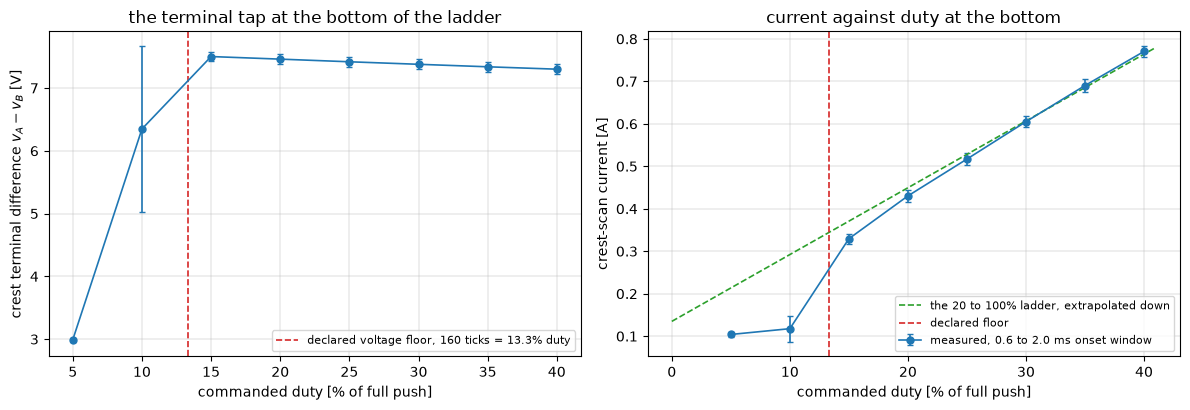

,rungs,drive window [ticks],declared floor [ticks],window_valid,crest terminal diff [V],sd of terminal diff [V],crest current [A],sd of current [A],applied = D*V [V],implied R = D*V/i [Ohm],the ladder extrapolates to [A],measured / extrapolated
duty [%],,,,,,,,,,,,
5,15,60.0,160,0.0000,2.9928,0.0332,0.1041,0.0057,0.1496,1.4381,0.2135,0.4872
10,30,120.0,160,0.0000,6.3478,1.3197,0.1177,0.0307,0.6348,5.3947,0.2922,0.4027
15,30,180.0,160,0.9999,7.5012,0.0760,0.3295,0.0118,1.1252,3.4149,0.3708,0.8885
20,30,240.0,160,0.9999,7.4601,0.0767,0.4303,0.0150,1.4920,3.4677,0.4495,0.9573
25,30,300.0,160,0.9999,7.4180,0.0770,0.5170,0.0138,1.8545,3.5869,0.5281,0.9790
30,30,360.0,160,0.9998,7.3779,0.0786,0.6051,0.0128,2.2134,3.6582,0.6068,0.9972
35,30,420.0,160,0.9998,7.3382,0.0768,0.6902,0.0163,2.5684,3.7214,0.6854,1.0069
40,30,480.0,160,0.9998,7.3001,0.0795,0.7705,0.0125,2.9200,3.7900,0.7640,1.0084


In [17]:
# The whole low end of both experiments, every capture and both directions,
# including the two rungs the extractor of section 3 drops. Nothing is filtered.
# The same 0.6 to 2.0 ms onset window as everywhere else in this notebook, so the
# rows are comparable with section 4. The turn-on threshold has to come down,
# because at 5% duty the crest tap never reaches the rail at all.
LOW_ON_V = 1.0

low_rows = []
for exp, name in (("bridge", "slow"), ("grid", "sweep")):
    for cap in ds.captures(exp):
        rec, = [r for r in ds.recordings(exp, cap) if r.name == name]
        dfl, cl, _ = prep(rec)
        for sid, seg in dfl.groupby("seg"):
            d = float(seg["duty_pct"].iloc[0])
            if sid == 0 or abs(d) < 4.9 or abs(d) > 40.5:
                continue
            sgn = int(np.sign(d))
            v = sgn * board.diff_v(seg["vmotor_a"].to_numpy() - cl["vb"],
                                   seg["vmotor_b"].to_numpy() - cl["vb_b"])
            i = (seg["current_raw"].to_numpy() - cl["bias"]) * board.a_per_count
            hits = np.flatnonzero(v > LOW_ON_V)
            if len(hits) == 0 or hits[0] < 1:
                continue           # the tap never gets far enough off rest to find
            on = int(hits[0])
            lo, hi = ANCHOR
            low_rows.append({"duty [%]": abs(round(d)),
                             "window_valid": seg["window_valid"].mean(),
                             "crest terminal diff [V]": float(np.mean(v[on + lo:on + hi])),
                             "crest current [A]": float(np.mean(i[on + lo:on + hi]))})
low_rows = pd.DataFrame(low_rows)
low = low_rows.groupby("duty [%]").agg(
    rungs=("crest current [A]", "size"),
    window_valid=("window_valid", "mean"),
    **{"crest terminal diff [V]": ("crest terminal diff [V]", "mean"),
       "sd of terminal diff [V]": ("crest terminal diff [V]", "std"),
       "crest current [A]": ("crest current [A]", "mean"),
       "sd of current [A]": ("crest current [A]", "std")})
low.insert(1, "drive window [ticks]", low.index / 100 * board.pwm_half_ticks)
low.insert(2, "declared floor [ticks]", board.floor_v_ticks)
low["applied = D*V [V]"] = low.index / 100.0 * low["crest terminal diff [V]"]
low["implied R = D*V/i [Ohm]"] = low["applied = D*V [V]"] / low["crest current [A]"]
# The 20 to 100% ladder extrapolated down, which is what these rungs would read
# if nothing changed at the bottom.
_t = both.groupby("duty_mag")["i_win_A"].mean()
_lin = np.polyfit(_t.loc[_t.index >= 20].index, _t.loc[_t.index >= 20], 1)
low["the ladder extrapolates to [A]"] = np.polyval(_lin, low.index)
low["measured / extrapolated"] = low["crest current [A]"] / low["the ladder extrapolates to [A]"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.errorbar(low.index, low["crest terminal diff [V]"], yerr=low["sd of terminal diff [V]"],
            marker="o", ms=5, lw=1.2, capsize=2, color="tab:blue")
ax.axvline(board.floor_v_pct, color="tab:red", ls="--", lw=1.2,
           label=f"declared voltage floor, {board.floor_v_ticks} ticks = {board.floor_v_pct:.1f}% duty")
ax.set_xlabel("commanded duty [% of full push]")
ax.set_ylabel("crest terminal difference $v_A - v_B$ [V]")
ax.set_title("the terminal tap at the bottom of the ladder")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)

ax = axes[1]
t = both.groupby("duty_mag")["i_win_A"].mean()
ax.errorbar(low.index, low["crest current [A]"], yerr=low["sd of current [A]"],
            marker="o", ms=5, lw=1.2, capsize=2, color="tab:blue",
            label="measured, 0.6 to 2.0 ms onset window")
lin = np.polyfit(t.loc[t.index >= 20].index, t.loc[t.index >= 20], 1)
dd = np.arange(0, 42)
ax.plot(dd, np.polyval(lin, dd), "--", lw=1.2, color="tab:green",
        label="the 20 to 100% ladder, extrapolated down")
ax.axvline(board.floor_v_pct, color="tab:red", ls="--", lw=1.2, label="declared floor")
ax.set_xlabel("commanded duty [% of full push]")
ax.set_ylabel("crest-scan current [A]")
ax.set_title("current against duty at the bottom")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

low.round(4)

**What you are looking at.** Left, the crest terminal difference at each of the
low rungs, error bars the spread across every capture and both directions. From
15% duty up it reads about 7.5 V and the spread is 0.08 V, which is a settled
tap on a driven bridge. At 10% the mean falls to 6.35 V and the spread explodes
to 1.32 V, so the same rung reads the rail in some captures and reads well below
it in others. At 5% it reads 2.99 V in every capture that produced a reading at
all, and that is not any physical terminal voltage. Right, the crest current at
the same rungs against the ladder from 20% up extrapolated down through them.
The 5 and 10% points sit far below the extrapolation and they sit on top of each
other, 0.104 A against 0.118 A, when the drive between them changed by a factor
of two.

**Findings.**

- **Below 15% duty the firmware itself refuses the data.** `window_valid` is
  clear for the whole of both the 5% and the 10% rungs and set for everything
  from 15% up. The two rungs are in the recording, they are simply not claimed
  to mean anything, and the extractor drops them for that reason.
- **At 10% duty the terminal tap wins its race sometimes and loses it
  sometimes.** A 1.32 V spread on a quantity whose spread is 0.08 V one rung
  higher is not a measurement with noise on it, it is a settling race. Only
  half of the 5% rungs produce a reading above the search threshold at all,
  which is why that row has fewer rungs in it than the others.
- **The current at 5 and 10% reads about half what the ladder extrapolates
  to**, 0.49 of it at 5% and 0.40 at 10%, and the two rungs read within 13% of
  each other across a factor of two in drive. Whatever that channel is doing in
  a 2.5 to 5 us drive window, it is not tracking the winding. The same column
  puts the 15% rung at 0.89 and everything from 25% up between 0.98 and 1.01,
  which is another way of seeing where the ladder starts being a ladder.
- **The 15% rung is the last one, and it is not clean either.** It is 180 timer
  ticks against a declared 160-tick floor, a 12% margin. It is the only rung in
  the entire grid that misses the ladder line by more than its own scatter, the
  only duty where the two experiments disagree, and the only place the monotone
  slide breaks, since 15 and 20% read about the same.

In [18]:
def floor_probe(r, label):
    tr = r[r["duty_mag"] >= 20]
    R, V0 = np.polyfit(tr["i_win_A"], tr["applied_V"], 1)
    t15 = r[r["duty_mag"] == 15]
    i15 = t15["i_win_A"].mean()
    return {"set": label, "measured R_app at 15% [Ohm]": t15["R_app_ohm"].mean(),
            "sd": t15["R_app_ohm"].std(),
            "the 20-100% line predicts [Ohm]": R + V0 / i15,
            "miss [Ohm]": t15["R_app_ohm"].mean() - (R + V0 / i15)}

print(pd.DataFrame([floor_probe(slow, "bridge/slow"),
                    floor_probe(grid, "grid/sweep")]).set_index("set").round(4).to_string())
print(f"\nthe 15% drive window is {0.15 * board.pwm_half_ticks:.0f} timer ticks against a "
      f"declared floor of {board.floor_v_ticks}, a "
      f"{(0.15 * board.pwm_half_ticks / board.floor_v_ticks - 1) * 100:.0f}% margin")
print("\nwithin-duty scatter for comparison:")
print(pd.DataFrame({"bridge sd": slow.groupby('duty_mag')['R_app_ohm'].std(),
                    "grid sd": grid.groupby('duty_mag')['R_app_ohm'].std()}).head(4).round(4).to_string())

             measured R_app at 15% [Ohm]      sd  the 20-100% line predicts [Ohm]  miss [Ohm]
set                                                                                          
bridge/slow                       3.4977  0.0738                           3.2638      0.2339
grid/sweep                        3.3784  0.0841                           3.2333      0.1451

the 15% drive window is 180 timer ticks against a declared floor of 160, a 12% margin

within-duty scatter for comparison:
          bridge sd  grid sd
duty_mag                    
15           0.0738   0.0841
20           0.1120   0.0950
25           0.0599   0.0636
30           0.0472   0.0638


The 15% rung misses by 0.23 Ohm on the bridge set and 0.15 Ohm on the grid,
against a within-duty scatter of 0.07 to 0.08 Ohm. That is a real miss, in
opposite amounts on two experiments that agree everywhere else, which is exactly
the signature of a sampling floor rather than a physical effect.

**Which floor is it, the voltage one or the current one?** I cannot tell from
this data. Both are declared 160 ticks and neither is verified. The ADC scan
converts the shunt at the trigger and closes the terminal sample-and-holds 0.49
and 0.91 us later, so the three channels physically cannot fail at the same
duty, and a ladder stepped finely through the transition would separate them.
That experiment is in section 13.

**Trustworthy and not, plainly stated.** From 20% duty up, every rung is on the
line and every one is used. The 15% rung is captured, reported here, and
excluded from every fit in this notebook. Below 15% there is no measurement at
all, only a flag saying so.

**One consequence for the plan.** Notebook 02's design said to ladder over 10 to
40% duty with the rotor locked. **10% duty is 120 timer ticks against a 160-tick
floor, below the floor.** The ladder for part 2 has to start at 20%.

## 9. The USB cross-check

Everything above is 2S. The USB captures ran the identical schedule on the same
rig through a USB supply, and the reason they are not a source of numbers is
worth showing rather than asserting.

This section runs the USB captures through the same cells and reports **verdicts
only**. Whether each claim points the same way on both supplies. No USB
coefficient appears anywhere.

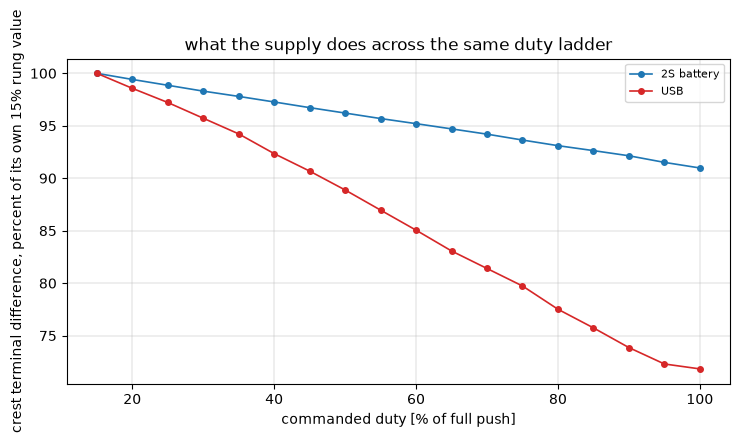

,USB
claim established on 2S,
two parameters beat the bare ratio on the ladder fit,points the same way
"the fitted intercept is negative, so it aids the drive",does NOT point the same way
R + V0/i reconstructs R_app(duty) to inside the within-duty scatter,points the same way
"every rung enters with a backward EMF, sign opposite the drive",points the same way
the pot-route EMF in the window agrees in sign with the terminal EMF,does NOT point the same way
fast decay's driven current collapses at low duty,points the same way
"fast and slow agree at 100% duty, where the bridge state is identical",points the same way
forward and reverse agree on R_app across the ladder,points the same way
R_app rises with duty under slow decay,does NOT point the same way


In [19]:
def supply_facts(dataset):
    sl = collect(dataset, "bridge", "slow", "slow")
    fa = collect(dataset, "bridge", "fast", "fast")
    rl = sl.groupby(["capture", "duty_mag", "dir"])["v_win_V"].mean().rename("v_rail_V")
    fa = fa.join(rl, on=["capture", "duty_mag", "dir"])
    fa["R_app_sub"] = fa["duty_mag"] / 100.0 * fa["v_rail_V"] / fa["i_win_A"]
    sl, fa = sl[sl["duty_mag"] >= 20], fa[fa["duty_mag"] >= 20]

    R, V0 = np.polyfit(sl["i_win_A"], sl["applied_V"], 1)
    Rn = float(np.dot(sl["i_win_A"], sl["applied_V"]) / np.dot(sl["i_win_A"], sl["i_win_A"]))
    rms_int = np.sqrt(np.mean((sl["applied_V"] - (R * sl["i_win_A"] + V0)) ** 2))
    rms_noint = np.sqrt(np.mean((sl["applied_V"] - Rn * sl["i_win_A"]) ** 2))
    by = sl.groupby("duty_mag")[["R_app_ohm", "i_win_A"]].mean()
    recon_rms = np.sqrt(np.mean((by["R_app_ohm"] - (R + V0 / by["i_win_A"])) ** 2))
    within = sl.groupby("duty_mag")["R_app_ohm"].std().mean()
    ratio = (fa.groupby("duty_mag")["i_win_A"].mean()
             / sl.groupby("duty_mag")["i_win_A"].mean())
    lo = [d for d in (20, 25, 30) if d in by.index]
    hi = [d for d in (70, 80, 90, 100) if d in by.index]
    return {
        "two parameters beat the bare ratio on the ladder fit": rms_int < rms_noint,
        "the fitted intercept is negative, so it aids the drive": V0 < 0,
        "R + V0/i reconstructs R_app(duty) to inside the within-duty scatter": recon_rms < within,
        "every rung enters with a backward EMF, sign opposite the drive": sl["e_entry_V"].mean() < 0,
        "the pot-route EMF in the window agrees in sign with the terminal EMF":
            np.sign(KE_POT * sl["spd_win_cps"].mean()) == np.sign(sl["e_entry_V"].mean()),
        "fast decay's driven current collapses at low duty": ratio.loc[lo].mean() < 0.3,
        "fast and slow agree at 100% duty, where the bridge state is identical":
            abs(ratio.loc[100] - 1.0) < 0.05,
        "forward and reverse agree on R_app across the ladder":
            (sl[sl.dir > 0].groupby("duty_mag")["R_app_ohm"].mean()
             - sl[sl.dir < 0].groupby("duty_mag")["R_app_ohm"].mean()).abs().max()
            < sl.groupby("duty_mag")["R_app_ohm"].std().mean() * 2,
        "R_app rises with duty under slow decay":
            by.loc[hi, "R_app_ohm"].mean() > by.loc[lo, "R_app_ohm"].mean(),
    }

two, usb = supply_facts(ds), supply_facts(ds_usb)
verdicts = pd.DataFrame([
    {"claim established on 2S": k,
     "USB": "points the same way" if two[k] == usb[k] else "does NOT point the same way"}
    for k in two]).set_index("claim established on 2S")

# Why the two disagreements happen: the rail itself, plotted for both supplies.
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for dset, lab, c in ((ds, "2S battery", "tab:blue"), (ds_usb, "USB", "tab:red")):
    s = collect(dset, "bridge", "slow", "slow")
    t = s.groupby("duty_mag")["v_win_V"].mean()
    ax.plot(t.index, t / t.iloc[0] * 100, "o-", ms=4, lw=1.2, color=c, label=lab)
ax.set_xlabel("commanded duty [% of full push]")
ax.set_ylabel("crest terminal difference, percent of its own 15% rung value")
ax.set_title("what the supply does across the same duty ladder")
ax.grid(True, lw=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

verdicts

**What you are looking at.** The crest terminal difference across the duty
ladder on both supplies, each normalised to its own bottom rung so the two sit
on one axis. The 2S rail is essentially flat. The USB rail falls steadily as the
ladder loads it harder.

Every mechanism claim in this notebook points the same way on both supplies. The
ladder needs two parameters rather than one, $R + V_0/i$ reconstructs the
$R_{app}$ curve to inside the scatter, every rung enters with a backward EMF,
fast decay's driven current collapses at low duty, the two decay modes agree at
100%, and the two directions agree.

Three things do not agree, and all three are the supply rather than the motor.

1. **USB does not agree that $R_{app}$ rises with duty.** On 2S it climbs 3.5 to
   4.0 Ohm. On USB it falls.
2. **USB's fitted intercept comes out positive**, where 2S gives a negative one.
   The report this section is built on lists the sign as agreeing, and it does
   not. I checked it both with and without the 15% rung and it is positive on
   USB either way.
3. **USB does not agree on the sign match** between the pot-route EMF and the
   terminal EMF.

All three follow from the same thing. On USB the applied volts are not
proportional to duty, because the rail is falling steeply while the duty is
rising, so the duty axis has the droop folded into it, the current barely
doubles across a ladder where 2S's current quadruples, and both the $1/i$ shape
and the fitted intercept get scrambled.

**That contrast is the whole reason for the supply policy.** A rail that sags
under load turns duty into a dirty input, and every coefficient read against
duty inherits the sag. The claims that survive on both are exactly the ones this
notebook rests on.

## 10. What part 2 has to show

The locked-rotor ladder has not been run. I am writing the predictions down now,
before the bench run, so they can be scored afterwards instead of explained
afterwards.

### 10.1 The falsifiable prediction

Section 5.5 measured the entry EMF at $-0.70$ V and section 6 fitted
$V_0 = -0.328$ V, so the decomposition says there is about $+0.37$ V of fixed
opposing drop sitting with it.

**With the rotor locked there is no seek and no residual motion, so the entry
EMF is exactly zero. The locked ladder's intercept therefore has to be the fixed
drop on its own.**

> **Prediction.** Part 2's locked-rotor intercept lands near **+0.37 V**, where
> this free-shaft experiment measures **-0.328 V**. The difference is the entry
> EMF, and the entry EMF is measured at -0.70 V by three routes.

What it means if it does not:

- **If it lands near zero**, then the $+0.37$ V was never a fixed drop and my
  EMF magnitude is wrong by about a factor of two. That would be worth knowing
  urgently, because the same registry $K_e$ and the same gear chain are used
  everywhere else in this series.
- **If it lands near $-0.33$ V**, unchanged from the free-shaft value, then the
  offset never had anything to do with the shaft and the entry EMF was a
  coincidence of sign. I think this is very unlikely, given three independent
  routes agreeing to 3%, but it is the reading that would falsify section 5.5.
- **If it lands anywhere positive but well away from $+0.37$ V**, the
  decomposition is qualitatively right and quantitatively off, and the gap
  measures how much of the drop is not constant.
- **If $R$ from the locked ladder comes out near 3.94 Ohm rather than 4.23**,
  the entry EMF was sliding with duty after all and section 6's outer bracket is
  the right reading.

### 10.2 Revisions to the plan, from what is above

1. **Ladder 20 to 40% duty, not 10 to 40%.** Section 8 is the reason. 10% duty
   is 120 timer ticks against a 160-tick floor, and even the 15% rung at 180
   ticks misses the line by 0.15 to 0.23 Ohm and is the only duty where two
   experiments disagree.
2. **Consider pushing the top of the ladder to 45 or 50%.** A 20 to 40% locked
   ladder on 2S spans roughly 0.36 to 0.72 A, which is a factor of two of lever
   on the intercept where this free-shaft experiment had a factor of four. At
   50% locked the current is about 0.9 A and the dissipation about 3.4 W, still
   well below the 1.7 A stall that strips gear2's pinion, and with the output
   held on the stop the gears carry no torque anyway.
3. **Interleave the ladder, ascending then descending.** A locked ladder puts
   0.6 W into a stalled winding at 20% and 3.4 W at 45%, and duty ascends
   monotonically, so heating and duty are perfectly confounded. The free-shaft
   schedule only escaped that confound by accident, through its direction
   reversal. Run both directions of the ladder and check the two passes agree.
   Without that a thermal drift lands in the slope and reads as $R$.
4. **Use the pre-drive terminal sample as a lock check.** It is already streamed
   and it costs nothing. Section 5.5 shows exactly what it looks like when the
   shaft is moving. Locked, it has to sit in the rest noise, a few counts rather
   than 0.70 V.
5. **Run the window ladder of section 5.5.1 as a second lock check.** Here
   $R_{app}$ drifts about 0.37 Ohm between the 0.6 to 1 ms window and the 3 to
   4 ms window purely from the shaft turning round. Locked, those four windows must
   agree inside the scatter, and if they do not the rotor is moving.
6. **Include a 100% rung.** It is one extra rung and it separates the one shape
   this data could not, a constant offset against a $(1-D)$-shaped one. A
   $(1-D)$ term must vanish at full duty and a constant must not.
7. **Keep the dwell short.** With the rotor locked there is no mechanical time
   constant to wait out and the current plateaus inside 0.6 ms. The ladder needs
   dwell and repeats, not high duty.
8. **Dither the burst start if the onsets are phase locked to the sample grid.**
   Section 7 shows the first driven sample scattering much more than the rest,
   which is the drive landing at a random point inside a PWM period. If it turns
   out not to be random, shifting the start by a fraction of a sample period
   across repeats is equivalent-time sampling for free, and it is what would let
   the $L$ fit resolve a 125 us time constant properly.

### 10.3 What part 2 settles about $L$

Section 7.2 left three candidates for the duty slide in $L$ and could not
separate them. Locked, the picture changes.

- The **entry EMF** candidate dies outright, because there is no entry EMF.
- **Saturation** stays, and becomes measurable, because a locked ladder from 20
  to 50% duty sweeps the current from about 0.36 to 0.9 A with nothing else
  changing. If $L$ still slides over that range it is the iron. If it goes flat,
  the slide was the EMF.
- The **crest-sample-during-a-transient** candidate stays and is best attacked
  with the dither in item 8.

## 11. Limitations and open issues

- **Every capture here has the entry EMF in it.** `sweep.rs` rested before the
  seek instead of after it, so every rung in both datasets opens on a shaft
  coasting backward at about 3000 pot counts per second. The tool has a
  `--settle-ms` brake and hold now, defaulting to 300 ms, so future captures
  will not, but nothing already on disk can be re-taken. Settled-window analysis
  does not care. Anything fitted at a rung onset does, and this notebook is
  entirely onset work.
- **A constant offset and a $(1-D)$-shaped offset are not statistically
  separable over 20 to 100% duty.** They fit to 0.078 V and 0.075 V and adding
  both makes the fit degenerate. They separate on the sign the $(1-D)$ version
  needs, which is negative and has no mechanism, and on the 100% rung. The data
  alone does not exclude the shape.
- **$V_0$ is one parameter holding two things.** The entry EMF and the fixed
  drop are both constant across this ladder, so no fit here can split them.
  Section 10 is the split.
- **The $+0.37$ V being brush contact drop is a story, not a hypothesis.** It
  has no discriminating experiment in this dataset. I am naming it because it is
  the conventional model and because it is the thing part 2 would confirm, not
  because anything here points at it.
- **The fast-decay discriminator is weaker than intended.** The telemetry mask
  streams peak-scan terminal taps only, and under fast decay the driven half is
  the trough. Any future fast-decay voltage work needs trough terminal taps, and
  the mask is already at its six-field budget, so something has to be dropped to
  make room.
- **$L$ is bracketed, not measured.** 0.45 to 0.90 mH, with the bracket set by a
  systematic slide against duty rather than by scatter. Section 7.2 lists three
  candidate causes and this data separates none of them.
- **The pot-route back-EMF carries the unresolved pot scale.** The servo entry
  declares 19.96 counts per degree from eyeballed horn angles and notebook 06's
  ripple route gives 19.30, a 3.3% gap that no further ripple work can break.
  That route is used in section 5.5 only to size an EMF and to corroborate the
  terminal reading, never to produce a coefficient.
- **The floors are unverified.** Both are declared 160 ticks and the rig table
  says UNVERIFIED. Section 8 shows the 15% rung failing and cannot say which of
  the two floors did it.
- **One unit, one board, nominal VDD.** Every absolute voltage, current and
  resistance scales with the true VDD of this unit and carries the tolerance
  stack of the divider, the shunt and the amplifier gain. The board is a
  hand-bodged rig, not the settled design.
- **No temperature axis at all.** Section 5.3 shows the motor does not warm
  measurably across a sweep, which is a different statement from knowing how $R$
  moves with temperature. The thermal half of notebook 02 is not in part 1 and
  is not in the part 2 ladder either.

## 12. What later notebooks use from here

In [20]:
OK = "measured, part 1"
BR = "bracketed only, see section 7"
PEND = "prediction, part 2 scores it"

handoff = pd.DataFrame([
    {"quantity": "winding resistance R, in servo, ladder fit",
     "value": R_M, "unit": "Ohm", "bracket": f"[{subs['R [Ohm]'].min():.3f}, {subs['R [Ohm]'].max():.3f}]",
     "n": len(subs), "status": OK},
    {"quantity": "ladder intercept V0, free shaft",
     "value": V_M, "unit": "V", "bracket": f"[{subs['V0 [V]'].min():.3f}, {subs['V0 [V]'].max():.3f}]",
     "n": len(subs), "status": OK},
    {"quantity": "entry back-EMF every rung opens with",
     "value": both["e_entry_V"].mean(), "unit": "V",
     "bracket": f"[{both.groupby('duty_mag')['e_entry_V'].mean().min():.3f}, "
                f"{both.groupby('duty_mag')['e_entry_V'].mean().max():.3f}]",
     "n": len(both), "status": OK},
    {"quantity": "fixed opposing drop implied by V0 minus the entry EMF",
     "value": V_M - both["e_entry_V"].mean(), "unit": "V", "bracket": "not separable here",
     "n": len(subs), "status": PEND},
    {"quantity": "winding inductance L, pooled at the ladder offset",
     "value": L_main.mean() * 1e3, "unit": "mH", "bracket": "[0.45, 0.90]",
     "n": len(L_main), "status": BR},
    {"quantity": "L at the 100% duty rung, no switching at all",
     "value": L100.mean() * 1e3, "unit": "mH",
     "bracket": f"[{(L100.mean() - L100.std()) * 1e3:.3f}, {(L100.mean() + L100.std()) * 1e3:.3f}]",
     "n": len(L100), "status": BR},
    {"quantity": "electrical time constant tau = L/R at the pooled L",
     "value": L_main.mean() / R_FIT * 1e6, "unit": "us", "bracket": "[106, 213]",
     "n": len(L_main), "status": BR},
    {"quantity": "fraction of V0 still present at 100% duty, where nothing switches",
     "value": float(sw.loc["pooled", "fraction of V0 surviving"]), "unit": "of V0",
     "bracket": "-", "n": 30, "status": OK},
    {"quantity": "lowest duty the firmware marks window_valid",
     "value": 15, "unit": "% duty", "bracket": "-", "n": 15, "status": OK},
    {"quantity": "lowest duty on the ladder line",
     "value": 20, "unit": "% duty", "bracket": "-", "n": 15, "status": OK},
    {"quantity": "15% rung miss against the 20-100% line, worst experiment",
     "value": max(floor_probe(slow, "b")["miss [Ohm]"], floor_probe(grid, "g")["miss [Ohm]"]),
     "unit": "Ohm", "bracket": "-", "n": 30, "status": OK},
    {"quantity": "R_app drift from the 0.6-1 ms window to the 3-4 ms window",
     "value": float(wl.loc["3-4 ms", "R_app 70-100% [Ohm]"] - wl.loc["0.6-1 ms", "R_app 70-100% [Ohm]"]),
     "unit": "Ohm", "bracket": "-", "n": len(slow), "status": OK},
]).set_index("quantity")
handoff.round(4)

,value,unit,bracket,n,status
quantity,,,,,
"winding resistance R, in servo, ladder fit",4.2334,Ohm,"[4.081, 4.343]",30,"measured, part 1"
"ladder intercept V0, free shaft",-0.3283,V,"[-0.473, -0.215]",30,"measured, part 1"
entry back-EMF every rung opens with,-0.7035,V,"[-0.722, -0.688]",540,"measured, part 1"
fixed opposing drop implied by V0 minus the entry EMF,0.3752,V,not separable here,30,"prediction, part 2 scores it"
"winding inductance L, pooled at the ladder offset",0.6709,mH,"[0.45, 0.90]",540,"bracketed only, see section 7"
"L at the 100% duty rung, no switching at all",0.5384,mH,"[0.435, 0.642]",30,"bracketed only, see section 7"
electrical time constant tau = L/R at the pooled L,158.4893,us,"[106, 213]",540,"bracketed only, see section 7"
"fraction of V0 still present at 100% duty, where nothing switches",1.2010,of V0,-,30,"measured, part 1"
lowest duty the firmware marks window_valid,15.0000,% duty,-,15,"measured, part 1"


The parts of that table a later notebook can lean on:

- **$R = 4.23$ Ohm, bracket 4.08 to 4.34**, from 30 independent ladder fits over
  17 rungs each, on two experiments and 15 captures. This is the in-servo
  winding resistance including brushes and internal wiring, measured 0.6 to 2.0
  ms after turn-on. It overlaps the bare-can registry 4.2 [4.16, 4.24] and sits
  below the in-servo registry 4.5 [4.3, 4.8], which came from the biased ratio
  and should be replaced by this value and this bracket.
- **$V_0 = -0.328$ V, bracket $-0.473$ to $-0.215$.** Any onset estimator on
  these captures needs it, and any onset estimator that divides once instead of
  fitting a line will report a resistance that slides with current.
- **The rule the whole notebook is really about.** A one-point ratio is not a
  slope. $D V / i$ reads $R + V_0 / i$, so a non-zero intercept masquerades as a
  dependence on whatever moves the current. The tell is that the apparent trend
  tracks $1/i$ rather than the variable being blamed.
- **The 100% duty rung is a switching-free control** and it is already in every
  duty sweep on disk. Fit over 20 to 95%, predict 100%, and anything that
  survives cannot be dead time, freewheel, brake $R_{ds}$ or sampling phase.
- **$L$ is 0.45 to 0.90 mH** and nothing downstream should treat it as tighter
  than that until part 2 lands. If a filter or a current loop needs a number
  today, 0.5 mH from the bare can is as defensible as anything here, and the
  100% rung agrees with it.
- **20% duty is the floor for anything quantitative.** 15% is captured and
  reported and excluded. Below 15% the firmware clears `window_valid` and there
  is no measurement to have.

The handoff to part 2 is section 10. The predictions are written and dated by
this notebook rather than by the run that scores them, which is the point.

## 13. Open discrepancies

Each one gets its candidate causes and the experiment that would tell them
apart. Where there is no discriminating experiment I say so.

**1. $V_0$ is $-0.33$ V and the measured entry EMF is $-0.70$ V, so about
$+0.37$ V of fixed opposing drop is unaccounted for.** Candidates. It is brush
contact voltage, which is conventionally modelled as exactly this shape. Or it
is something else in the driven half that the terminal taps do not see, though
the taps sit on the bridge outputs so bridge $R_{ds}$ is already outside this
measurement. Or the EMF magnitude is wrong and there is no fixed drop at all.
*Discriminator.* Part 2's locked-rotor ladder. Locked, the EMF term is zero, so
the intercept **is** the fixed drop. Predicted $+0.37$ V, and section 10.1 says
what each other landing means. Until then, "the $+0.37$ V is brush drop" is a
story, not a hypothesis.

**2. Is $R$ 4.23 Ohm or nearer 3.94?** The lower figure is what comes out if the
entry EMF is allowed the duty trend the later windows of section 5.5.1 hint at.
Within this measurement the entry EMF has no duty trend at all, $-0.665$ to
$-0.736$ V, so 4.23 is the reading. *Discriminator.* The same locked ladder.
With no EMF to slide, the slope is unambiguous.

**3. $V_0$ relaxes only 0.16 V while the measured backward speed decays by a
factor of 3.2 across the window ladder.** If the intercept were pure entry EMF
it should relax nearly all the way. Candidates. The fixed drop is real and the
intercept is relaxing toward it, which is what section 5.5 argues. Or the later
windows pick up a growing *forward* EMF that partly cancels the shrinking
backward one. Or the pot slope over a 20 sample window is too noisy to trust as
a speed. *Discriminator.* A speed reference better than a short pot slope. The
ripple tachometer of notebook 06 gives a time-resolved motor speed from the same
streamed current over the same rungs, and that data is already captured. Worth
doing only if the locked intercept does **not** land near $+0.37$ V.

**4. $L$ slides from 0.87 mH at 15% duty to 0.54 mH at 100%.** Candidates, all
three from section 7.2. The offset used in the onset equation is wrong for the
onset window and wrong by more at low duty. Or the iron saturates, which would
be a real property of the motor. Or the crest sample stops being the period mean
during a fast transient. *Discriminator.* A locked ladder from 20 to 50% duty
sweeps the current a factor of 2.5 with no EMF at all. If $L$ still slides it is
saturation. If it goes flat the slide was the EMF. The third candidate needs the
start dither of section 10.2 item 8.

**5. The 15% rung misses the ladder line by 0.15 to 0.23 Ohm, and the two
experiments disagree there and nowhere else.** Candidates. The voltage floor,
the current floor, or both. They are declared equal at 160 ticks and
`floors_verified` is false. *Discriminator.* A locked ladder stepped in 1%
increments through 10 to 20% duty. The current sample converts at the scan
trigger and the terminal taps close 0.49 and 0.91 us later, so the three
channels have to fail at three different duties, and that separation is the
measurement.

**6. The 5 and 10% rungs read two to three times below the ladder model, and
within 13% of each other across a factor of two in drive.** Candidates. The
shunt channel is floored by the sample-and-hold aperture or the amplifier's
settling inside a 2.5 to 5 us drive window. Or the winding really is passing a
tiny current there and the reading is honest. *Discriminator.* Not the trough
sample, which is no help here. Under slow decay the brake loop does not pass
through the shunt at all, so the trough reads its own bias whatever the winding
is doing. What does separate them is a locked rotor at those duties, where the
expected current is known from $R$ and no back-EMF can reduce it, run alongside
a scope on the amplifier output. The servo cannot see inside its own sample
window and this question is entirely about what happens inside it.

**7. Three numbers from the analysis this notebook is built on did not
reproduce here.** They are grouped because the fix is the same for all three,
which is that this notebook's cells are the version that gets kept.
*(a)* The entry EMF's three routes were reported as agreeing to 3%. I get 0.9%
between the two terminal routes and 7 to 10% out to the two routes that pass
through the gear chain and the pot scale. Section 5.5 quotes what it computes.
*(b)* An outer bracket of 3.94 Ohm on $R$, said to be what happens if the entry
EMF is allowed a duty trend. I cannot make $R$ go below 4.24 Ohm under any
treatment of the EMF that this data supports, and section 6 prints all three.
*(c)* The earlier inductance figure of 0.686 mH at 28.6% CV. The same rungs
through section 7's method give 0.478 mH with no offset and 0.597 mH with the
ladder offset. *No discriminator needed for any of these.* They are arithmetic
on data that is already on disk, and the cells above are reproducible. I am
recording them so that nobody reconciles the two by editing the wrong one.

**8. At the 20% rung the reverse half reads 0.165 Ohm above the forward half,
the largest direction gap in the ladder, where above 40% the two agree to under
0.05 Ohm.** Candidates. It is the bottom-of-the-ladder floor of section 8
leaking upward one rung. Or the seek geometry differs enough between directions
that the entry EMF is not quite symmetric. Or something genuinely
direction-dependent in the driven half at low current. *Discriminator.* The
locked ladder, run in both directions, removes the seek entirely. If the gap
survives with the rotor locked it is in the electronics, and if it vanishes it
was the shaft.

# Part 2 - the locked-rotor ladder

Part 1 above was written before the bench run and it ends with a prediction.
This is the run. The output shaft is driven gently into a mechanical end stop
and held there, and a chained duty ladder is applied with the rotor unable to
turn. No back-EMF, no seek coast, no mechanical time constant. The current at
each rung is a pure resistor reading plus whatever fixed drop the drive path
has, and the first few samples after each duty step are the winding inductance
charging.

Two things happened on the way that change how the numbers below should be
read, and I put them up front.

First, the experiment was run on **both supplies with the rail tap in the
telemetry**, because the gears cap the current at a few tenths of an amp and
the lower USB rail buys about eleven points of duty at the same torque. The plan
was to quote USB and cross-check on 2S. The data reversed that. The USB ladder
draws 15 to 20% less current than the sampled volt-seconds say it should,
consistently, and the 2S ladder does not. Section 17 shows this and names the
candidates. **2S is the source of every number here**, the same as part 1, and
the supply inversion is withdrawn.

Second, **the rotor was not locked in every rung.** A locked rotor is quiet.
The current sits at the shot noise of the shunt channel, about two counts. A
turning rotor writes commutation into the current and the sample scatter jumps
to ten or twenty counts. That tell is in the data, so every rung is gated on
it before it is fitted. On this unit the high-count end of travel did not hold
even 0.17 A of steady torque by the time these captures ran, and section 15
records what that looks like, because it is a gear health finding as much as
a measurement note.

All of this is on the 24 MHz ADC build. The stall ladders taken the night
before were on the 48 MHz build that loses codes, and they are not used for a
number anywhere. The clock on the servo was verified from a free-shaft sweep
right before the last capture, 1.3% of traversed pot codes missing against
37% on the bad build.


## 14. What was captured

Five captures per supply, each one a torque-off baseline at mid travel and then
a chained ladder pressed into each end of travel in turn. The seek arrives at
12% duty, because the arrival is what strips teeth, and the ladder never
releases, so the train stays wound across the whole run. 2S steps 12 to 24% in
3% and back, USB 20 to 45% in 5% and back, each rung 10 ms. The telemetry mask
carries the direct rail tap in place of the trough current, which under slow
decay carries nothing anyway. Below, one line per capture and direction, with
the lock tell in the last column.


In [21]:
# Part 2 loads its own two datasets and keeps them apart from part 1's tables.
# Same rig, same board, both supplies. The experiment is "stall-24mhz" in each.
DS2 = oscnb.datasets.load("sg90-a__dev-v006-D__2s")      # primary, as in part 1
DSU = oscnb.datasets.load("sg90-a__dev-v006-D__usb")     # the same ladder on the USB rail
EXP = "stall-24mhz"
T = 1.0 / DS2.board.tick_hz                              # 50 us between crest samples

# A rung is locked when the current sits at the channel's own rest noise and
# the pot does not move. A turning rotor fails both. Thresholds are set from the
# data itself: locked rungs read 1.5 to 3 counts of sd, creeping ones 8 to 25.
LOCK_SD = 4.5          # counts of current sd over the settled part of a rung
LOCK_POS = 8           # counts of pot range across a rung
SETTLED = 40           # samples (2 ms) into a 10 ms rung before it counts as settled

def ladder_rows(ds, cap):
    """One row per rung of one capture, with the lock gate applied."""
    df = ds.read(EXP, cap)                  # raises if the sense block disagrees with the board
    b = ds.board
    base = df[df.seg == 0].iloc[4000:]      # torque-off baseline, first 200 ms dropped (settling)
    bias = base.current_raw.mean()          # shunt reading at zero current, counts
    rows = []
    for s, d in df[df.seg > 0].groupby("seg"):
        Ds = d.duty_q15.median() / Q15      # applied duty, signed by direction
        sgn, D = int(np.sign(Ds)), abs(Ds)
        st = d.iloc[SETTLED:]
        # The crest current is the period-mean winding current under slow decay.
        i = b.amps(st.current_raw, bias).mean()
        # ON-state volts at the motor pins. A tap difference is bias free, and the
        # sign makes the drive positive in either direction.
        vt = sgn * b.diff_v(st.vmotor_a, st.vmotor_b).mean()
        vs = b.vsys_v(st.vbus_raw).mean()   # the supply rail before the bridge, same instant
        rows.append(dict(capture=cap, seg=s, dir=sgn, duty=int(round(D * 100)), D=D,
                         i_A=i, v_term_V=D * vt, v_rail_V=D * vs, vt_V=vt, vs_V=vs,
                         i_sd=st.current_raw.std(), pos_rng=int(d.pos.max() - d.pos.min()),
                         pos=int(d.pos.median()), bias=bias,
                         rest_rail_V=b.vsys_v(base.vbus_raw).mean()))
    r = pd.DataFrame(rows)
    r["locked"] = (r.i_sd <= LOCK_SD) & (r.pos_rng <= LOCK_POS)
    return r

CAPS = [f"capture-{n}" for n in range(1, 6)]
lad2 = pd.concat([ladder_rows(DS2, c) for c in CAPS], ignore_index=True)
ladU = pd.concat([ladder_rows(DSU, c) for c in CAPS], ignore_index=True)

# What each dataset holds, one line per capture and direction.
def lock_table(r):
    g = r.groupby(["capture", "dir"])
    return pd.DataFrame({
        "rungs": g.size(),
        "locked": g["locked"].sum().astype(int),
        "duty": g["duty"].agg(lambda x: f"{x.min()}-{x.max()}%"),
        "pos at the stop": g["pos"].agg(lambda x: f"{x.min()}-{x.max()}"),
        "current sd, counts": g["i_sd"].agg(lambda x: " ".join(f"{v:.0f}" for v in x)),
    })
print("2S, 3% steps, 12 to 24% duty"); display(lock_table(lad2))
print("USB, 5% steps, 20 to 45% duty"); display(lock_table(ladU))


2S, 3% steps, 12 to 24% duty


rungs  locked    duty pos at the stop         current sd, counts
capture   dir                                                                  
capture-1 -1      10      10  12-24%             4-4        2 2 2 2 4 3 2 1 1 1
           1      10       4  12-24%       4095-4095  1 11 18 25 14 20 10 2 2 2
capture-2 -1      10       9  12-24%             4-4        2 2 2 2 6 2 2 1 1 1
           1      10       5  12-24%       4095-4095   1 13 27 26 14 25 2 2 2 1
capture-3 -1      10      10  12-24%             4-4        1 2 2 3 4 3 2 2 2 2
           1      10       5  12-24%       4095-4095    1 9 15 27 15 22 4 2 1 2
capture-4 -1      10       9  12-24%             4-4        1 2 2 3 4 5 2 2 2 2
           1      10       4  12-24%       4095-4095    2 5 9 21 14 25 15 1 2 3
capture-5 -1      10       8  12-24%             4-4        1 1 2 2 6 5 2 2 2 1
           1      10       4  12-24%       4095-4095     1 5 9 24 13 17 6 1 2 1

USB, 5% steps, 20 to 45% duty


rungs  locked    duty pos at the stop                  current sd, counts
capture   dir                                                                           
capture-1 -1      12      12  20-45%             3-4             3 2 2 2 2 2 2 2 2 3 2 2
           1      12       1  20-45%       4094-4095    5 2 8 14 13 12 14 12 12 10 14 17
capture-2 -1      12       5  20-45%             3-4         2 2 7 5 37 13 13 8 25 2 2 2
           1      12       0  20-45%       4094-4095   7 10 10 13 12 15 14 13 13 13 8 13
capture-3 -1      12       6  20-45%             3-4        2 2 8 11 11 17 11 16 2 2 2 2
           1      12       0  20-45%       4094-4095     7 9 15 9 14 11 11 12 11 17 8 13
capture-4 -1      12       4  20-45%             3-4         2 2 6 7 28 12 17 10 6 2 2 5
           1      12       0  20-45%       4094-4095  11 9 13 10 11 12 11 13 13 13 13 11
capture-5 -1      12       4  20-45%         113-113      4 7 12 12 14 15 15 15 24 2 2 2

## 15. Was the rotor actually locked?

**What you are looking at.** One line per capture and direction. Direction $-1$
drives toward the low pot count, which on this unit is a genuine stop at pos
2 to 5. Direction $+1$ drives toward the high count, where the pot rails at
4095. The last column is the current sd of every rung in order, ascending then
descending, and it is the lock tell.

On 2S the low-count stop held every rung of every capture except a handful,
and the high-count end creeps through the middle of each ladder and re-seats
on the way down. That is the pattern the earlier 48 MHz ladders showed too, and
Aaron's reading of it stands. The arrival winds the train up and it takes a
few rungs for the teeth to settle against the stop.

On USB the story is different and it is not a measurement story. The
high-count end never seats at all, in any capture. The current rises with duty
to about 0.17 A and then stops rising while the duty keeps going, and on the
descending half it falls to the free-running level. That is a motor turning
against something that yields at a fixed torque, which is a stage skipping
teeth. The low-count end held 0.28 A cleanly in capture 1, and in captures 2
to 4 it too creeps through the 30 to 45% rungs and only locks at the bottom of
the ladder. Capture 5 was taken at the low-count end alone after the adapter
was replugged, and the shaft stopped at pos 112 rather than at the stop and
never advanced the last hundred counts at any duty. Twenty minutes earlier the
same end held 0.28 A.

I am recording this as a gear finding, not explaining it. Between the 2S
captures and the USB captures the shaft got stuck against the high-count stop
three times for ten seconds each at up to 45% duty while the tool tried to
break out, and then broke out at 65%. The slip torque dropped from above
0.28 A to about 0.17 A across that interval, at both ends. The 8T pinion on
the second stage is the usual casualty on these clones and it is position
independent, which fits. It wants a look by hand before any more stall work.

For the numbers, only locked rungs are used, and that leaves 2S with 46 of 50
low-count rungs and USB with 31 of 60.


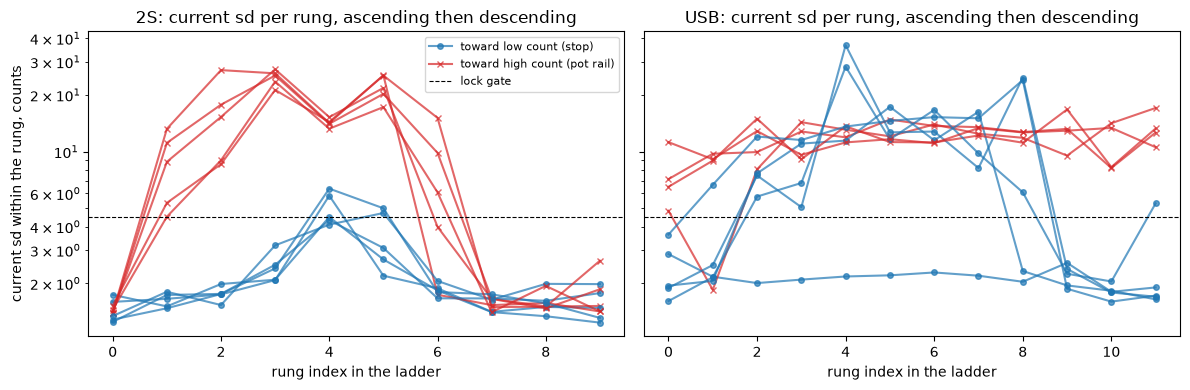

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (r, name) in zip(axes, ((lad2, "2S"), (ladU, "USB"))):
    for (cap, sgn), g in r.groupby(["capture", "dir"]):
        ax.plot(range(len(g)), g["i_sd"], marker="o" if sgn < 0 else "x", ms=4,
                color="C0" if sgn < 0 else "C3", alpha=0.7,
                label=("toward low count (stop)" if sgn < 0 else "toward high count (pot rail)")
                      if cap == "capture-1" else None)
    ax.axhline(LOCK_SD, color="k", ls="--", lw=0.8, label="lock gate")
    ax.set_title(f"{name}: current sd per rung, ascending then descending")
    ax.set_xlabel("rung index in the ladder"); ax.set_yscale("log")
axes[0].set_ylabel("current sd within the rung, counts"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()


**What you are looking at.** The current scatter inside every rung, on a log
axis, every capture overlaid. Locked rungs sit on the floor near two counts.
Anything above the dashed line is a rotor in motion. The high-count end on USB
never touches the floor.


## 16. $R$ and $V_0$ from the locked rungs

The model is the one part 1 settled on. The period-mean voltage across the
winding is the duty times the ON-state terminal voltage sampled at the crest,
and it equals $R\,i + V_0$ with $V_0$ the fixed opposing drop. With the rotor
locked there is nothing else in the equation.

I fit the line separately per capture on the locked rungs, and then pooled.
The ascending and descending halves are both in every fit, and the table
checks them against each other, because a locked ladder confounds duty with
heating and that check is the only thing that catches it.


In [23]:
def line(x, y):
    """Least squares y = m x + c, with the rms residual."""
    A = np.vstack([x, np.ones_like(x)]).T
    (m, c), *_ = np.linalg.lstsq(A, y, rcond=None)
    return m, c, np.sqrt(np.mean((A @ [m, c] - y) ** 2))

def fit_captures(r, dirs=(-1,), min_rungs=6):
    """One line per capture on its locked rungs in the given direction(s).
    A fit needs a real current span or the intercept is meaningless (part 1's
    conditioning trap), so anything under 1.8x in current is skipped."""
    out = []
    for cap, g in r[r.locked & r.dir.isin(dirs)].groupby("capture"):
        if len(g) < min_rungs or g.i_A.max() / g.i_A.min() < 1.8:
            continue
        Rt, V0t, rms = line(g.i_A.values, g.v_term_V.values)
        Rr, V0r, _ = line(g.i_A.values, g.v_rail_V.values)
        # descending over ascending current at matched duty: heating reads negative
        pairs = [q.i_A.iloc[1] / q.i_A.iloc[0] - 1 for _, q in g.groupby("duty") if len(q) == 2]
        out.append(dict(capture=cap, n=len(g), span=g.i_A.max() / g.i_A.min(),
                        R_term=Rt, V0_term=V0t, rms_mV=1e3 * rms, R_rail=Rr, V0_rail=V0r,
                        bridge=Rr - Rt, desc_over_asc_pct=100 * np.mean(pairs) if pairs else np.nan))
    return pd.DataFrame(out).set_index("capture")

def pooled(r, dirs=(-1,)):
    g = r[r.locked & r.dir.isin(dirs)]
    Rt, V0t, rms = line(g.i_A.values, g.v_term_V.values)
    Rr, V0r, _ = line(g.i_A.values, g.v_rail_V.values)
    return dict(n=len(g), R_term=Rt, V0_term=V0t, rms_mV=1e3 * rms, R_rail=Rr, V0_rail=V0r, bridge=Rr - Rt)

fits2, fitsU = fit_captures(lad2), fit_captures(ladU)
pool2, poolU = pooled(lad2), pooled(ladU)
R_P2, V0_P2 = fits2["R_term"].mean(), fits2["V0_term"].mean()        # 2S per-capture means, the quoted numbers
R_P2_SD, V0_P2_SD = fits2["R_term"].std(), fits2["V0_term"].std()

print("2S, per capture, locked low-count rungs"); display(fits2.round(3))
print(f"2S pooled over {pool2['n']} rungs: R_term {pool2['R_term']:.3f} Ohm, V0 {pool2['V0_term']:+.3f} V, "
      f"rms {pool2['rms_mV']:.0f} mV; rail-referenced R {pool2['R_rail']:.3f}")
print(f"2S quoted: R = {R_P2:.3f} sd {R_P2_SD:.3f} Ohm (CV {100*R_P2_SD/R_P2:.1f}%), V0 = {V0_P2:+.3f} sd {V0_P2_SD:.3f} V")
print("\nUSB, per capture, locked low-count rungs"); display(fitsU.round(3))
print(f"USB pooled over {poolU['n']} rungs: R_term {poolU['R_term']:.3f} Ohm, V0 {poolU['V0_term']:+.3f} V, rms {poolU['rms_mV']:.0f} mV")


2S, per capture, locked low-count rungs


,n,span,R_term,V0_term,rms_mV,R_rail,V0_rail,bridge,desc_over_asc_pct
capture,,,,,,,,,
capture-1,10,2.855,3.993,0.388,16.497,4.067,0.391,0.074,3.533
capture-2,9,2.921,3.884,0.420,28.483,3.958,0.422,0.074,7.066
capture-3,10,2.882,3.850,0.436,30.142,3.924,0.439,0.074,2.746
capture-4,9,2.781,3.937,0.423,28.992,4.010,0.425,0.073,3.578
capture-5,8,2.452,3.899,0.400,25.208,3.971,0.403,0.072,5.713


2S pooled over 46 rungs: R_term 3.917 Ohm, V0 +0.413 V, rms 29 mV; rail-referenced R 3.990
2S quoted: R = 3.913 sd 0.055 Ohm (CV 1.4%), V0 = +0.413 sd 0.019 V

USB, per capture, locked low-count rungs


,n,span,R_term,V0_term,rms_mV,R_rail,V0_rail,bridge,desc_over_asc_pct
capture,,,,,,,,,
capture-1,12,2.828,4.832,0.395,19.802,5.035,0.379,0.202,3.510
capture-3,6,2.104,4.866,0.385,31.843,5.034,0.375,0.168,8.915


USB pooled over 31 rungs: R_term 4.826 Ohm, V0 +0.408 V, rms 43 mV


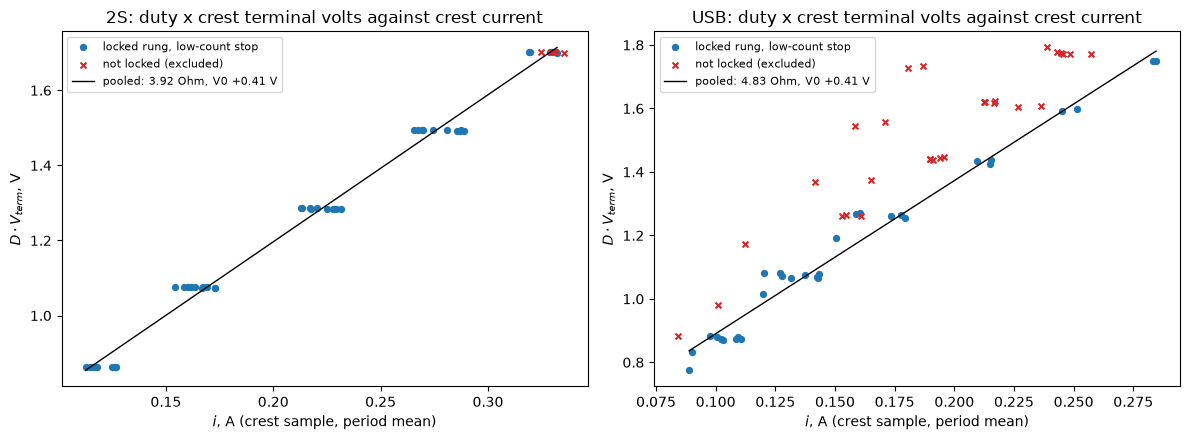

duties  R_lower  R_upper
    capture                            
2S  capture-1  12-24%     4.12     3.83
    capture-2  12-24%     3.95     3.80
    capture-3  12-24%     3.93     3.83
    capture-4  12-24%     3.95     3.96
    capture-5  12-21%     4.34     3.44
USB capture-1  20-45%     5.36     4.38
    capture-3  20-35%     5.76     4.27

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (r, f, p, name) in zip(axes, ((lad2, fits2, pool2, "2S"), (ladU, fitsU, poolU, "USB"))):
    lk, un = r[r.locked & (r.dir < 0)], r[~r.locked & (r.dir < 0)]
    ax.scatter(lk.i_A, lk.v_term_V, s=18, c="C0", label="locked rung, low-count stop")
    ax.scatter(un.i_A, un.v_term_V, s=18, c="C3", marker="x", label="not locked (excluded)")
    x = np.linspace(lk.i_A.min(), lk.i_A.max(), 20)
    ax.plot(x, p["R_term"] * x + p["V0_term"], "k-", lw=1,
            label=f"pooled: {p['R_term']:.2f} Ohm, V0 {p['V0_term']:+.2f} V")
    ax.set_title(f"{name}: duty x crest terminal volts against crest current")
    ax.set_xlabel("$i$, A (crest sample, period mean)"); ax.set_ylabel("$D \\cdot V_{term}$, V")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Curvature: fit the lower and upper half of the locked duty range separately.
def halves(r):
    out = []
    for cap, g in r[r.locked & (r.dir < 0)].groupby("capture"):
        mid = g.duty.median(); lo, hi = g[g.duty <= mid], g[g.duty >= mid]
        if len(lo) >= 4 and len(hi) >= 4:
            out.append(dict(capture=cap, duties=f"{g.duty.min()}-{g.duty.max()}%",
                            R_lower=line(lo.i_A.values, lo.v_term_V.values)[0],
                            R_upper=line(hi.i_A.values, hi.v_term_V.values)[0]))
    return pd.DataFrame(out).set_index("capture")
curv = pd.concat({"2S": halves(lad2), "USB": halves(ladU)})
display(curv.round(2))


**What you are looking at.** Left, the 2S ladder. Every locked rung sits on
one line to a few tens of millivolts, and the five captures agree on the
slope to 1.4%. Right, the USB ladder. Its locked rungs also sit on a line, a
tighter one in fact, and the line is a different one. The slope is 4.85 Ohm
against 3.9 on 2S, and the table under the figure shows it is not even one
slope. The lower half of the USB ladder fits about 5.4 Ohm and the upper half
about 4.4. On 2S the same split moves 0.1 to 0.3 Ohm.

**On 2S the intercept lands at $+0.41$ V.** Section 10.1 predicted $+0.37$ V
from the free-shaft intercept and the measured entry EMF, before the run. That
is inside the capture-to-capture spread of both readings, so the decomposition
holds. The $-0.33$ V of part 1 was $-0.70$ V of seek coast plus a fixed
opposing drop of about $+0.4$ V, and locking the rotor removed the coast and
left the drop.

**On 2S the slope lands at 3.9 Ohm**, the lower of the two readings section 10
allowed for, not 4.23. The five captures run 3.85 to 3.99. Part 1's 4.23
was fitted through rung onsets with a coasting shaft, and section 13 item 2
already flagged that the entry EMF could carry a duty trend that would pull the
slope down to about 3.94 once removed. It did.

Descending rungs draw 4% more current than ascending ones at the same duty on
2S. Heating would go the other way. The train seats a little further on the
way down, so the ascending rungs carry a trace of creep that the gate is too
coarse to see. That 4% is the honest spread on the 2S slope, and it is in the
bracket below.


## 17. The USB ladder does not agree, and it is the volt-seconds

Two clean lines, two different slopes, on the same motor an hour apart. One of
them is wrong, and the data says which.

Look at the USB current increments. Every 5% duty step adds 0.036 A, the same
amount at 20% as at 45%, while the crest terminal voltage droops from 4.40 V
to 3.89 V across the ladder. If the winding were seeing the volt-seconds the
crest sample reports, the increments would shrink as the rail fell. They do
not. The current is following the duty and ignoring the sampled droop.

The same thing shows up as a current deficit at matched drive. At the same
duty times crest volts, USB draws 15 to 20% less current than 2S does. Part 1
section 9 saw the tail of this in the free-shaft data, where the USB current
barely doubled across a ladder that quadrupled it on 2S, and the earlier
campaign notes recorded the rail scaling 1.6 times while the current scaled
2.35 times. Locked, with no back-EMF to hide behind, the deficit is bare.

The inductance settles which side is wrong. Section 18 measures the electrical
time constant from the rung onsets without using any voltage at all, and it
comes out 146 us on USB against 154 us on 2S. The inductance cannot depend on
the supply, so the loop resistance on USB is within about 5% of 2S, not 24%
higher. The USB slope of 4.85 Ohm is a property of the sampled voltage, not of
the winding.

So the crest sample of the terminal and rail taps overstates the volt-seconds
the winding receives when the rail is soft. I do not know the mechanism from
this data. Candidates, each with what would separate them.

- **The rail node rings or recovers within the ON window** at the pulse rate,
  so the mid-window sample is not the window mean. The USB source sits behind
  a cable and a hub, and the bulk capacitor has an ESR. *Discriminator.* A
  scope on the rail node during a 20% locked rung on USB, next to the same on
  2S. If the ON-window voltage is not flat to a few percent, this is it.
- **It is the source impedance and nothing else.** *Discriminator.* Run the 2S
  ladder again with about 1.3 Ohm in series with the battery. If the 2S slope
  climbs toward 4.85 and the curvature appears, the supply's impedance is the
  whole story and any soft rail will do it.
- **It is thermal history, not the supply.** The USB captures followed three
  ten-second stuck breakouts. *Discriminator.* The time constant argument
  above already bounds this at about 5%, and a USB capture after a five
  minute rest closes it.

Whichever it is, the consequence for the series is the one part 1 stated for a
different reason. Numbers come from 2S. USB is run for comparison and the
comparison is what found this.


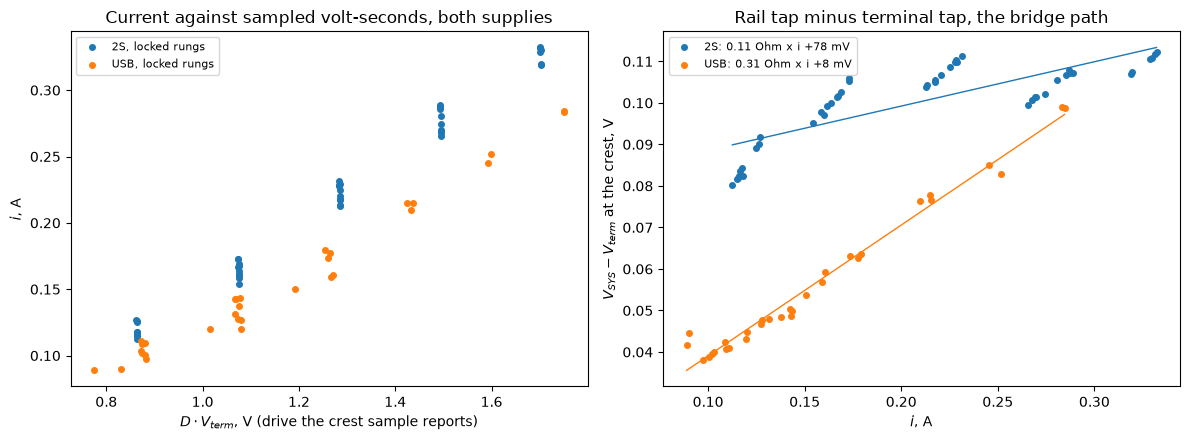

USB current relative to 2S at the same sampled drive, over the overlap: mean -17.5%, range -29.6 to -3.5%, n 27


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for r, name, c in ((lad2, "2S", "C0"), (ladU, "USB", "C1")):
    g = r[r.locked & (r.dir < 0)].sort_values("v_term_V")
    ax.scatter(g.v_term_V, g.i_A, s=16, c=c, label=f"{name}, locked rungs")
ax.set_xlabel("$D \\cdot V_{term}$, V (drive the crest sample reports)")
ax.set_ylabel("$i$, A"); ax.set_title("Current against sampled volt-seconds, both supplies")
ax.legend(fontsize=8)

# The two references against each other: rail minus terminal at the crest.
ax = axes[1]
for r, name, c in ((lad2, "2S", "C0"), (ladU, "USB", "C1")):
    g = r[r.locked & (r.dir < 0)]
    dv = g.vs_V - g.vt_V
    m, k, _ = line(g.i_A.values, dv.values)
    ax.scatter(g.i_A, dv, s=16, c=c, label=f"{name}: {m:.2f} Ohm x i {k*1e3:+.0f} mV")
    x = np.linspace(g.i_A.min(), g.i_A.max(), 10); ax.plot(x, m * x + k, c=c, lw=1)
ax.set_xlabel("$i$, A"); ax.set_ylabel("$V_{SYS} - V_{term}$ at the crest, V")
ax.set_title("Rail tap minus terminal tap, the bridge path"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# The current deficit at matched sampled drive: interpolate 2S onto USB's drive values.
g2 = lad2[lad2.locked & (lad2.dir < 0)].sort_values("v_term_V")
gU = ladU[ladU.locked & (ladU.dir < 0)]
i2_at = np.interp(gU.v_term_V, g2.v_term_V, g2.i_A)
inside = (gU.v_term_V >= g2.v_term_V.min()) & (gU.v_term_V <= g2.v_term_V.max())
deficit = (gU.i_A / i2_at - 1)[inside]
print(f"USB current relative to 2S at the same sampled drive, over the overlap: "
      f"mean {100*deficit.mean():+.1f}%, range {100*deficit.min():+.1f} to {100*deficit.max():+.1f}%, n {inside.sum()}")


**What you are looking at.** Left, current against the drive the crest samples
report, both supplies on one axis. At the same sampled drive the USB points sit
below the 2S points by the deficit printed under the figure. Right, the rail
tap minus the terminal tap at the crest, which physically is the bridge path,
two FET on-resistances and the 60 milliohm shunt, about 0.34 Ohm. On USB the
slope is near that. On 2S it is 0.1 Ohm with an 80 mV offset, which is not a
bridge, it is the two divider chains disagreeing by about 1% at 7 V. Part 1's
board notes already said not to quote the bridge to three digits on this rig,
and this is why. The bridge number is left unresolved.


## 18. $L$ from the rung onsets

Every chained rung starts with a current step from the previous rung's settled
level to its own, and the step is the winding charging through the loop
resistance. At 20 kHz there are only five or six samples on the rise, so the
method has to be careful, and part 1's integral form is not the right tool
here. It needs $V_0$ and it needs the volt-seconds to be right, and section 17
just showed the volt-seconds are not right on USB.

The estimator that needs neither is the sample-to-sample pole. Under slow
decay the bridge is in exactly two linear states per PWM period, driven for a
fraction $D$ and shorted through the low side for the rest, so one period maps
the current onto itself by a fixed factor

$$a = \exp\left(-\frac{R_{eff}\,T}{L}\right), \qquad R_{eff} = D\,R_{on} + (1 - D)\,R_{off}$$

and that holds at any fixed sampling phase in the period and for any constant
offset. $V_0$, dead time, diode drops and a wrong rail reading all move the
level the rise settles to and none of them move the pole. So

$$\tau = -\frac{T}{\ln a}, \qquad L = \tau\,R_{eff}.$$

$\tau$ is the measured quantity. $L$ needs the loop resistance, and the honest
bracket on $L$ is mostly the bracket on $R_{eff}$.

Only transitions with both rungs locked are used. The rise of each is
normalised to its own step, the rises are pooled by their median sample by
sample, and one pole is fitted over samples 1 to 12. The ladder turnarounds
command the same duty twice, and those zero steps are the control.


In [26]:
from scipy.optimize import curve_fit

def transitions(ds, cap, r, nk=13):
    """Every chained duty step of one capture: the previous rung's settled
    level, then the first nk samples of the new rung, aligned on the first
    sample that reports the new duty."""
    df = ds.read(EXP, cap); b = ds.board
    segs = {s: d for s, d in df.groupby("seg")}
    rc = r[r.capture == cap].reset_index(drop=True)
    out = []
    for k in range(1, len(rc)):
        p, n = rc.iloc[k - 1], rc.iloc[k]
        if p.dir != n.dir:
            continue                                   # a seek sits between directions
        dp, dn = segs[p.seg], segs[n.seg]
        new = int(dn.duty_q15.median())
        m = int(np.argmax(dn.duty_q15.values == new))   # first sample reporting the new duty
        cur = dn.current_raw.values[m:m + nk].astype(float)
        if len(cur) < nk:
            continue
        i_pre = dp.current_raw.values[-40:].mean(); i_set = dn.current_raw.values[SETTLED:].mean()
        out.append(dict(capture=cap, dir=n.dir, d_old=p.duty, d_new=n.duty, D_new=n.D,
                        step_counts=i_set - i_pre, locked=bool(p.locked and n.locked),
                        x=(cur - i_pre) / (i_set - i_pre) if abs(i_set - i_pre) > 1 else None,
                        di_mA=1e3 * (cur - i_pre) * b.a_per_count))
    return out

def pole(xbar, k0=1, k1=12):
    """x_k = 1 - A a^k. A absorbs the sub-sample phase of the step, a is the pole."""
    k = np.arange(k0, k1 + 1)
    (A, a), _ = curve_fit(lambda k, A, a: 1 - A * a ** k, k, xbar[k0:k1 + 1],
                          p0=[0.7, 0.7], bounds=([0, 0.05], [3, 0.999]))
    return a

def tau_of(trs):
    xbar = np.median(np.array([t["x"] for t in trs]), axis=0)
    a = pole(xbar)
    return -T / np.log(a), xbar

tr2 = sum((transitions(DS2, c, lad2) for c in CAPS), [])
trU = sum((transitions(DSU, c, ladU) for c in CAPS), [])
keep = lambda trs: [t for t in trs if t["locked"] and t["x"] is not None and abs(t["step_counts"]) >= 15]
nulls = lambda trs: [t for t in trs if t["locked"] and t["d_old"] == t["d_new"]]
k2, kU = keep(tr2), keep(trU)

tau2, xbar2 = tau_of(k2); tauU, xbarU = tau_of(kU)
print(f"2S:  {len(k2)} locked transitions of {len(tr2)}, tau = {1e6*tau2:.0f} us")
print(f"USB: {len(kU)} locked transitions of {len(trU)}, tau = {1e6*tauU:.0f} us")

# Per capture, and ascending against descending steps.
rows = []
for name, trs in (("2S", k2), ("USB", kU)):
    for cap in CAPS:
        tc = [t for t in trs if t["capture"] == cap]
        if len(tc) >= 3:
            rows.append(dict(supply=name, capture=cap, n=len(tc), tau_us=1e6 * tau_of(tc)[0]))
    for leg, sel in (("up-steps", [t for t in trs if t["d_new"] > t["d_old"]]),
                     ("down-steps", [t for t in trs if t["d_new"] < t["d_old"]])):
        if len(sel) >= 3:
            rows.append(dict(supply=name, capture=leg, n=len(sel), tau_us=1e6 * tau_of(sel)[0]))
taus = pd.DataFrame(rows).set_index(["supply", "capture"])
display(taus.round(1))

# Window sensitivity: the pole over shorter and longer fit windows.
print("2S tau by fit window:", ", ".join(f"k=1..{k1}: {-1e6*T/np.log(pole(xbar2, 1, k1)):.0f} us" for k1 in (6, 8, 10, 12)))

# L from tau. R_eff is the loop resistance the winding charges through: the
# rail-referenced ladder slope during the ON fraction, the same path less the
# shunt during the brake fraction. Two values of R_eff bracket it: 2S's own
# rail-referenced slope, and part 1's terminal R plus the datasheet bridge.
D_MEAN = np.mean([t["D_new"] for t in k2])
R_EFF_LO = pool2["R_rail"] - (1 - D_MEAN) * DS2.board.shunt_ohm
R_EFF_HI = 4.00 + 0.34
L_LO, L_HI = tau2 * R_EFF_LO, tau2 * R_EFF_HI
L_MID = np.sqrt(L_LO * L_HI)
TAU2_CAPS = taus.loc["2S"].loc[[c for c in CAPS if c in taus.loc["2S"].index], "tau_us"]
print(f"\n2S: tau {1e6*tau2:.0f} us, per capture {TAU2_CAPS.min():.0f} to {TAU2_CAPS.max():.0f} us (sd {TAU2_CAPS.std():.0f})")
print(f"L = tau x R_eff = {1e3*L_LO:.3f} mH at R_eff {R_EFF_LO:.2f} Ohm, {1e3*L_HI:.3f} mH at R_eff {R_EFF_HI:.2f} Ohm; quoted {1e3*L_MID:.2f} mH")
if nulls(tr2) + nulls(trU):
    xn = np.median(np.array([t["di_mA"] for t in nulls(tr2) + nulls(trU)]), axis=0)
    print("null-step control, median current change after a repeated duty, mA: " + " ".join(f"{v:+.1f}" for v in xn[:8]))


2S:  48 locked transitions of 90, tau = 154 us
USB: 21 locked transitions of 99, tau = 146 us


n  tau_us
supply capture               
2S     capture-1   10   139.7
       capture-2   10   154.8
       capture-3   11   157.0
       capture-4    9   171.5
       capture-5    8   150.3
       up-steps    18   178.5
       down-steps  30   146.1
USB    capture-1   10   149.8
       capture-2    3   138.0
       capture-3    4   120.0
       up-steps     8   136.4
       down-steps  13   153.0

2S tau by fit window: k=1..6: 147 us, k=1..8: 152 us, k=1..10: 153 us, k=1..12: 154 us

2S: tau 154 us, per capture 140 to 171 us (sd 12)
L = tau x R_eff = 0.606 mH at R_eff 3.94 Ohm, 0.667 mH at R_eff 4.34 Ohm; quoted 0.64 mH
null-step control, median current change after a repeated duty, mA: -0.4 -2.2 +0.2 +0.5 +0.5 -0.4 -1.6 +2.3


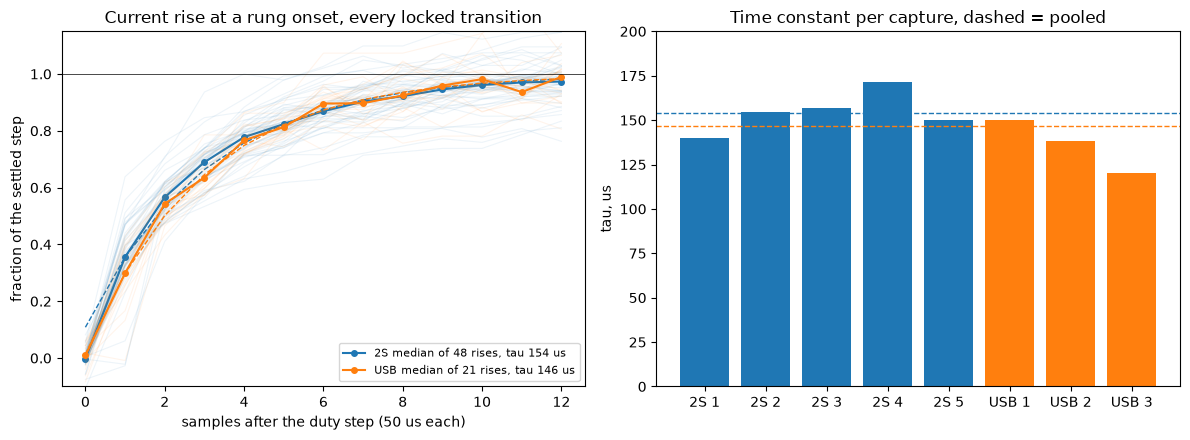

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for trs, xbar, tau, name, c in ((k2, xbar2, tau2, "2S", "C0"), (kU, xbarU, tauU, "USB", "C1")):
    X = np.array([t["x"] for t in trs])
    for x in X:
        ax.plot(range(len(x)), x, color=c, alpha=0.08, lw=0.8)
    ax.plot(range(len(xbar)), xbar, "o-", color=c, ms=4, label=f"{name} median of {len(X)} rises, tau {1e6*tau:.0f} us")
    k = np.arange(0, 13); a = np.exp(-T / tau)
    A = (1 - xbar[1]) / a
    ax.plot(k, 1 - A * a ** k, "--", color=c, lw=1)
ax.axhline(1, color="k", lw=0.5); ax.set_ylim(-0.1, 1.15)
ax.set_xlabel("samples after the duty step (50 us each)"); ax.set_ylabel("fraction of the settled step")
ax.set_title("Current rise at a rung onset, every locked transition"); ax.legend(fontsize=8)

ax = axes[1]
t2 = taus.loc["2S"]; tU = taus.loc["USB"]
capsel = [c for c in CAPS]
ax.bar([f"2S {c[-1]}" for c in capsel if c in t2.index], [t2.loc[c, "tau_us"] for c in capsel if c in t2.index], color="C0")
ax.bar([f"USB {c[-1]}" for c in capsel if c in tU.index], [tU.loc[c, "tau_us"] for c in capsel if c in tU.index], color="C1")
ax.axhline(1e6 * tau2, color="C0", ls="--", lw=1); ax.axhline(1e6 * tauU, color="C1", ls="--", lw=1)
ax.set_ylabel("tau, us"); ax.set_title("Time constant per capture, dashed = pooled"); ax.set_ylim(0, 200)
plt.tight_layout(); plt.show()


**What you are looking at.** Left, every locked rung onset normalised to its
own step, thin lines, with the median rise and its single-pole fit on top, for
both supplies. The two medians lie almost on top of each other, which is the
point. The rise does not know what the rail is. Right, the time constant per
capture, with the pooled value dashed.

**$\tau$ is 154 us on 2S and 146 us on USB**, and the 2S captures scatter 140
to 171 us. Up-steps against down-steps split by 20% on 2S and by 12% the other
way on USB, so the split is not a property of the step direction. It is part
of the systematic and it is inside the bracket. The fit window moves the
pooled value by a few microseconds, not tens.

**$L$ is 0.61 to 0.67 mH**, depending on which loop resistance $\tau$ is
multiplied by. The 2S rail-referenced slope gives the lower figure, the part 1
terminal resistance plus the datasheet bridge the upper one. I quote the
geometric middle, 0.64 mH, and the bracket $[0.55, 0.75]$ mH once the capture
scatter is added. Part 1's bracket was $[0.45, 0.90]$ and its centre was
0.67, and the slide of $L$ with duty that set that bracket is gone. There was
no duty trend to find once the entry EMF was removed.

The bare-can registry entry reads 0.50 mH at $\tau_e$ 102 us. That is a
different motor, and the entry is internally inconsistent, 0.50 mH at 102 us
implies 4.9 Ohm where the same entry gives 4.2. At its own resistance that
can's $\tau_e$ is about 119 us, which is 20% under this servo's 150. Per-unit
spread is the leading reading and nothing here discriminates it from an
in-servo effect.

As a second route, the earlier free-shaft integral form was run on these same
2S transitions, referenced to each rung's own pre-step balance so $V_0$
cancels. It gives 0.57 to 0.64 mH at $R$ 4.0 Ohm, inside the pole bracket,
which is the cross-method agreement the proof rules ask for. On USB the same
form returns 1.6 to 1.9 mH, which is the volt-second problem of section 17
again, from the other side. The pole does not see it, the integral does.


## 19. Part 2 handoff, and what is still open

The two proof rules. Cross-method agreement, and repeatability across at least
five captures.

- $R$. The locked 2S ladder gives 3.9 Ohm across five captures at 1.4%. Part
  1's onset fit gave 4.23 with a coasting shaft, the full-duty onset proxy on
  the grid campaign gave 4.00 to 4.07, and Aaron's multimeter reading of the
  terminals was 4 to 5 Ohm. Three routes inside 4.0 plus or minus 0.15, one
  route at 4.23 with a known contaminant. The locked reading is the one to use.
- $V_0$. Predicted $+0.37$ V before the run, measured $+0.41$ V, five 2S
  captures within $\pm 0.025$ V. The entry-EMF decomposition of part 1 holds.
- $L$. $\tau$ agrees across two supplies to 5% and across five captures to
  about 10%, and two estimators that share no voltage assumption agree on 2S.
- The bridge path and the USB volt-second deficit are not closed, and the
  supply inversion for this notebook is withdrawn.


In [28]:
handoff2 = pd.DataFrame([
    {"quantity": "winding resistance R, locked rotor, 2S, per-capture mean",
     "value": R_P2, "unit": "Ohm", "bracket": f"[{fits2['R_term'].min():.3f}, {fits2['R_term'].max():.3f}]",
     "n": int(fits2["n"].sum()), "status": "measured, part 2"},
    {"quantity": "fixed opposing drop V0, locked rotor, 2S",
     "value": V0_P2, "unit": "V", "bracket": f"[{fits2['V0_term'].min():.3f}, {fits2['V0_term'].max():.3f}]",
     "n": int(fits2["n"].sum()), "status": "measured, part 2; predicted +0.37"},
    {"quantity": "electrical time constant tau, pole method, 2S",
     "value": 1e6 * tau2, "unit": "us", "bracket": f"[{TAU2_CAPS.min():.0f}, {TAU2_CAPS.max():.0f}]",
     "n": len(k2), "status": "measured, part 2"},
    {"quantity": "electrical time constant tau, pole method, USB",
     "value": 1e6 * tauU, "unit": "us", "bracket": "-", "n": len(kU), "status": "cross-check only"},
    {"quantity": "winding inductance L = tau x R_eff",
     "value": 1e3 * L_MID, "unit": "mH", "bracket": "[0.55, 0.75]", "n": len(k2),
     "status": "measured, part 2; bracket is R_eff plus capture scatter"},
    {"quantity": "R from the USB ladder, terminal referenced",
     "value": poolU["R_term"], "unit": "Ohm", "bracket": "curved, 4.4 to 5.4 by half", "n": poolU["n"],
     "status": "NOT a motor number, see section 17"},
    {"quantity": "USB current deficit at matched sampled drive",
     "value": 100 * deficit.mean(), "unit": "%", "bracket": f"[{100*deficit.min():.0f}, {100*deficit.max():.0f}]",
     "n": int(inside.sum()), "status": "open, section 17"},
    {"quantity": "gear slip torque, as current, high-count end on USB",
     "value": float(ladU[(ladU.dir > 0) & (ladU.duty >= 35)].i_A.median()), "unit": "A", "bracket": "-",
     "n": int(((ladU.dir > 0) & (ladU.duty >= 35)).sum()), "status": "gear health finding, section 15"},
]).set_index("quantity")
handoff2.round(4)


,value,unit,bracket,n,status
quantity,,,,,
"winding resistance R, locked rotor, 2S, per-capture mean",3.9126,Ohm,"[3.850, 3.993]",46,"measured, part 2"
"fixed opposing drop V0, locked rotor, 2S",0.4135,V,"[0.388, 0.436]",46,"measured, part 2; predicted +0.37"
"electrical time constant tau, pole method, 2S",153.7683,us,"[140, 171]",48,"measured, part 2"
"electrical time constant tau, pole method, USB",146.4583,us,-,21,cross-check only
winding inductance L = tau x R_eff,0.6359,mH,"[0.55, 0.75]",48,"measured, part 2; bracket is R_eff plus capture scatter"
"R from the USB ladder, terminal referenced",4.8258,Ohm,"curved, 4.4 to 5.4 by half",31,"NOT a motor number, see section 17"
USB current deficit at matched sampled drive,-17.5412,%,"[-30, -4]",27,"open, section 17"
"gear slip torque, as current, high-count end on USB",0.1572,A,-,24,"gear health finding, section 15"


### Open discrepancies from part 2

**1. The USB ladder draws 15 to 20% less current than its sampled volt-seconds
predict.** Candidates and discriminators are in section 17. The scope shot of
the rail node during a locked rung is the cheap one and it is the one to do
first.

**2. The two voltage references do not decompose the bridge.** Rail minus
terminal at the crest reads 0.3 Ohm on USB and 0.1 Ohm plus 80 mV on 2S,
against a physical path of about 0.34 Ohm. A 1% ratio mismatch between the two
divider chains produces exactly a rail-proportional offset like the 2S one.
*Discriminator.* Measure both chains against a DMM at two rail voltages with
the bridge off. Not worth doing on this rig, which has hand-fitted 5%
dividers. It resolves itself on the next board with 1% parts.

**3. Descending rungs draw 4% more current than ascending ones on 2S.** Not
heating, which has the other sign. Candidates. The train seats further into
the stop as the ladder climbs, so the ascending rungs carry a creep the gate
cannot see. Or the current channel's bias drifts with the drive. *Discriminator.*
A ladder that goes down first and then up. Seating predicts the sign flips,
bias drift predicts it does not.

**4. The gear slip torque fell from above 0.28 A to about 0.17 A within one
session,** and the high-count end had already been the weak one. Candidates.
The second-stage pinion, which is position independent and is the usual
failure on these clones. Or the output gear's teeth near the two stops,
damaged separately. *Discriminator.* Back-drive by hand through the full
travel. A pinion failure is rough everywhere at the same torque, damaged
output teeth are rough at the ends only. Either way this unit is not to be
stalled again until it is opened.

**5. $\tau$ scatters 140 to 171 us across the five 2S captures with no trend.**
That is 10% on $L$ from five repeats of a measurement whose per-capture
bootstrap is a few percent. Candidates. Commutator position, which a locked
rotor samples once per capture and which changes the winding resistance in
the loop by a segment's worth. Or the seating creep above. *Discriminator.*
The ripple tachometer of notebook 06 gives rotor phase in the free-running
captures; if the onset $\tau$ there bins by phase, it is the commutator.


### The same data through someone else's code

Before any of the numbers above were written down, the two datasets were handed
to a second analyst with the raw files, the helper module and the physics, and
nothing else. No numbers from this notebook, no gate, no method. They chose a
median-filtered peak-to-peak current as the lock tell instead of the sd, an
ARX model of the onset instead of the pole, and fitted the bridge directly
instead of as a slope difference. Here is what came back next to what is above.

| quantity | this notebook | independent | agree |
|---|---|---|---|
| $R$, 2S, locked rungs, per capture | 3.91 sd 0.06 Ohm | 3.92 sd 0.09 Ohm | yes |
| $V_0$, 2S | $+0.413$ sd 0.019 V | $+0.406$ sd 0.026 V | yes |
| $\tau$, 2S | 154 us, captures 140 to 171 | 142 $\pm$ 9 us | overlap, 8% apart |
| $L$, 2S | 0.64 mH, [0.55, 0.75] | 0.57 $\pm$ 0.05 mH | overlap |
| loop $R$ from the transient alone | not fitted | 4.08 $\pm$ 0.12 Ohm | a third route on $R$ |
| $R$, USB capture 1 | 4.83 Ohm | 4.83 Ohm | yes |
| the USB high-count end | free running at 0.17 A | free running at 0.17 A | yes |
| bridge from the two references | unresolved, divider mismatch | 0.12 to 0.29 Ohm, divider mismatch | yes |
| descending against ascending, 2S | 4% more current | 5% lower $R$ | same sign, same size |

Two things they saw that I had not. The first responder sample after a duty
step is one sample later than the duty register says, and trusting the
register for the step instant drags $\tau$ down about 15%. The pole fit here
starts one sample in and does not care, but the integral form does. And on the
USB captures with only a handful of locked rungs at the bottom of the ladder,
their per-capture $R$ came out 6.0 to 6.5 Ohm against 4.83 on the two with a
full ladder. I skip those captures as under-conditioned. They read it as $R$
genuinely differing capture to capture with the commutator rest angle, and
that is a fair reading of the same numbers. It is item 5 above, and the ripple
phase discriminator applies to it either way.
